Análise completa de portfolio

In [1]:
# ==============================================================================
# CÉLULA 1: IMPORTAÇÕES E CONFIGURAÇÃO INICIAL
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import yfinance as yf
import datetime
import json
from scipy import stats

# Configuração Visual
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("tab10")

# --- FUNÇÕES DE SUPORTE ---

def parse_pt_date(date_str):
    """Converte datas em português (ex: 'jan-22') para datetime."""
    month_map = {
        'janeiro': 1, 'fevereiro': 2, 'março': 3, 'abril': 4, 'maio': 5, 'junho': 6,
        'julho': 7, 'agosto': 8, 'setembro': 9, 'outubro': 10, 'novembro': 11, 'dezembro': 12,
        'jan': 1, 'fev': 2, 'mar': 3, 'abr': 4, 'mai': 5, 'jun': 6,
        'jul': 7, 'ago': 8, 'set': 9, 'out': 10, 'nov': 11, 'dez': 12
    }
    try:
        if isinstance(date_str, (pd.Timestamp, datetime.datetime)): return date_str # verifica se 
        # a variável date_str já é do tipo pd.Timestamp OU do tipo datetime.datetime.
        # Caso seja, a função retorna a própria variável date_str sem realizar nenhuma conversão adicional. 
        # Isso é útil para evitar erros de conversão quando a data já está no formato correto.
        parts = str(date_str).split('-')
        # if len(parts) != 2: return pd.NaT # comentado para ficar mais robusto a formatos variados
        month_name = parts[0].lower().strip() # remove espaços em branco e converte para minúsculas
        year_full = 2000 + int(parts[1]) # assume anos no formato '22' como 2022
        return pd.Timestamp(year=year_full, month=month_map.get(month_name, 1), day=1) + pd.offsets.MonthEnd(0) 
        # converte para o último dia do mês
    except:
        # return pd.NaT # comentado para ficar mais robusto a formatos variados
        raise ValueError("VERIFICAR FORMATO DA DATA: " + str(date_str))

def get_cdi_local(file_path, start_date, end_date):
    """Lê o CDI de arquivo Excel local."""
    print(f"Lendo CDI local: {file_path}...")
    try:
        cdi = pd.read_excel(file_path)
        cdi.columns.values[0] = 'data_raw'
        cdi.columns.values[1] = 'valor'
        
        def parse_ipea_date(val):
            # Se for float, força 2 casas decimais (ex: 2022.1 -> "2022.10")
            if isinstance(val, (float, int)):
                val_str = f"{val:.2f}"
            else:
                val_str = str(val).strip()

            if '.' in val_str:
                parts = val_str.split('.')
                year = int(parts[0])
                month = int(parts[1])
                return pd.Timestamp(year=year, month=month, day=1) + pd.offsets.MonthEnd(0)
        
            return pd.to_datetime(val) + pd.offsets.MonthEnd(0)

        cdi['data'] = cdi['data_raw'].apply(parse_ipea_date)
        cdi = cdi.dropna(subset=['data']).set_index('data').sort_index()
        
        if cdi['valor'].dtype == object:
            cdi['valor'] = cdi['valor'].astype(str).str.replace(',', '.').astype(float)
            
        mask = (cdi.index >= pd.to_datetime(start_date)) & (cdi.index <= pd.to_datetime(end_date))
        cdi = cdi.loc[mask]
        cdi['monthly_decimal'] = cdi['valor'] / 100
        # return cdi['monthly_decimal'].resample('ME').last()
        return cdi['monthly_decimal'].resample('ME').apply(lambda x: np.prod(1+x)-1) # para calcular o >
        # > CDI mensal composto corretamente, mesmo quando há mais de um valor por mês.
    except Exception as e:
        print(f"ERRO ao ler CDI: {e}")
        return None

In [2]:
# ==============================================================================
# CÉLULA 2: CLASSES E MÉTODOS PARA MANIPULAÇÃO DE DADOS E CÁLCULO DE MÉTRICAS
# ==============================================================================

import pandas as pd
import numpy as np
from typing import Tuple, List, Optional

class PortfolioMetrics:
    """
    Calculates quantitative KPIs for a dataframe containing monthly asset returns.
    The class is designed to be flexible and reusable, allowing for easy extension with additional metrics if needed.
    """
    def __init__(self, returns_df: pd.DataFrame, risk_free_col: str = 'CDI', market_col: str = 'Global_BRL'):
        # Data is safely anchored to the object
        self.returns = returns_df
        self.rf_col = risk_free_col
        self.mkt_col = market_col
        
        # Identify all assets to be analyzed
        self.assets: List[str] = self.returns.columns.tolist() # Lista de colunas do DataFrame, 
        # que representa os ativos a serem analisados.
        
        # Financial periods parameter (monthly data = 12 periods per year)
        self.periods_per_year = 12
        self.total_years = len(self.returns) / self.periods_per_year
        
        # Pre-calculate the Risk-Free CAGR since it acts as the MAR (Minimum Acceptable Return)
        # using the exact compounding logic from the original notebook
        rf_total_ret = (1 + self.returns[self.rf_col]).prod() - 1
        self.rf_cagr = (1 + rf_total_ret) ** (1 / self.total_years) - 1

    def calc_cagr(self, ticker: str) -> float:
        """Calculates the Compound Annual Growth Rate using monthly returns."""
        total_ret = (1 + self.returns[ticker]).prod() - 1 # constrói o fator de riqueza acumulado ao
        #multiplicar sucessivamente todos os fatores de retorno mensal
        return (1 + total_ret) ** (1 / self.total_years) - 1 # converte o retorno total acumulado em um CAGR anualizado

    def calc_volatility(self, ticker: str) -> float:
        """Calculates annualized volatility assuming homoscedasticity."""
        return self.returns[ticker].std() * np.sqrt(self.periods_per_year) # desvio padrão mensal multiplicado
        # pela raiz de 12 para anualizar e partindo do pressuposto de homocedasticidade — 
        # a premissa de que a variância escala de forma linear com o tempo e, portanto, o desvio-padrão
        # escala com a raiz quadrada do tempo.

    def calc_max_drawdown(self, ticker: str) -> float:
        """Calculates the absolute maximum drawdown from the equity curve."""
        wealth = (1 + self.returns[ticker]).cumprod() # constrói o fator de riqueza acumulado ao multiplicar
        # sucessivamente todos os fatores de retorno mensal
        drawdown = (wealth - wealth.cummax()) / wealth.cummax() # calcula o drawdown como a queda percentual do pico histórico
        return drawdown.min()

    def calc_sharpe(self, ticker: str) -> float:
        """Calculates the annualized Sharpe Ratio against the defined risk-free rate."""
        if ticker == self.rf_col: # O Índice de Sharpe para o próprio ativo de referência (CDI) é zero, 
            #pois não há excesso de retorno.
            return 0.0
            
        excess_ret = self.returns[ticker] - self.returns[self.rf_col]
        if excess_ret.std() == 0:
            return 0.0
            
        return (excess_ret.mean() / excess_ret.std()) * np.sqrt(self.periods_per_year)

    def calc_sortino(self, ticker: str, mar_type: str = 'risk_free', custom_mar: float = 0.0) -> float:
        """
        Calculates the Sortino Ratio allowing for a dynamic Minimum Acceptable Return (MAR).
        Instead of filtering strictly < 0, it penalizes returns below the chosen MAR.
        """
        # Determine the annualized and monthly MAR based on the user selection
        if mar_type == 'risk_free':
            mar_annual = self.rf_cagr
            mar_monthly_series = self.returns[self.rf_col]
        elif mar_type == 'zero':
            mar_annual = 0.0
            mar_monthly_series = 0.0
        else:
            mar_annual = custom_mar
            # Convert annual custom MAR to a monthly geometric equivalent
            mar_monthly_series = (1 + custom_mar) ** (1 / self.periods_per_year) - 1
            
        cagr = self.calc_cagr(ticker)
        
        # Calculate excess returns relative to the chosen monthly MAR
        excess = self.returns[ticker] - mar_monthly_series
        
        # Isolate downside risk using numpy (values below the chosen MAR)
        downside = np.where(excess < 0, excess, 0)
        
        downside_vol = np.sqrt(np.mean(downside**2)) * np.sqrt(self.periods_per_year)
        
        # Prevent division by zero
        if downside_vol == 0:
            return 0.0
            
        return (cagr - mar_annual) / downside_vol

    def calc_adjusted_sortino(self, ticker: str, mar_type: str = 'risk_free') -> float:
        """
        Calculates the Adjusted Sortino Ratio (Classic Sortino / sqrt(2)).
        This makes it directly comparable to the Sharpe Ratio under normal distribution assumptions.
        """
        classic_sortino = self.calc_sortino(ticker, mar_type=mar_type)
        return classic_sortino / np.sqrt(2)

    def calc_beta_alpha(self, ticker: str) -> Tuple[float, float]:
        """
        Calculates Beta and Annualized Alpha using Covariance/Variance.
        Returns a Tuple containing (Beta, Alpha).
        """
        if ticker == self.rf_col:
            return 0.0, 0.0
            
        excess_asset = self.returns[ticker] - self.returns[self.rf_col]
        excess_mkt = self.returns[self.mkt_col] - self.returns[self.rf_col]
        
        # Align data dropping NaNs
        df = pd.concat([excess_asset, excess_mkt], axis=1).dropna()
        df.columns = ['y', 'x']
        
        variance = df['x'].var()
        if len(df) < 6 or variance == 0:
            return np.nan, np.nan
            
        covariance = df.cov().iloc[0, 1]
        beta = covariance / variance
        
        # Alpha calculation
        alpha_monthly = df['y'].mean() - beta * df['x'].mean()
        alpha_annual = ((1 + alpha_monthly) ** self.periods_per_year) - 1
        
        return beta, alpha_annual

    def calc_calmar(self, ticker: str) -> float:
        """Calculates the Calmar Ratio."""
        cagr = self.calc_cagr(ticker)
        max_dd = self.calc_max_drawdown(ticker)
        
        if max_dd == 0:
            return 0.0
            
        return cagr / abs(max_dd)

    def calc_tracking_error(self, ticker: str) -> float:
        """Calculates the annualized Tracking Error against the market benchmark."""
        # The benchmark has no tracking error against itself
        if ticker == self.mkt_col:
            return 0.0
            
        active_returns = self.returns[ticker] - self.returns[self.mkt_col]
        
        # Prevent math errors if series are perfectly identical
        if active_returns.std() == 0:
            return 0.0
            
        return active_returns.std() * np.sqrt(self.periods_per_year)

    def calc_information_ratio(self, ticker: str) -> float:
        """Calculates the Information Ratio (Active Return / Tracking Error)."""
        if ticker == self.mkt_col:
            return 0.0
            
        active_returns = self.returns[ticker] - self.returns[self.mkt_col]
        tracking_error = self.calc_tracking_error(ticker)
        
        if tracking_error == 0:
            return 0.0
            
        # Annualized mean active return divided by annualized tracking error
        annualized_active_return = active_returns.mean() * self.periods_per_year
        return annualized_active_return / tracking_error

    def calc_max_drawdown_duration(self, ticker: str) -> int:
        """
        Calculates the maximum time under water (in months).
        Returns the longest consecutive period where the equity curve was below its previous peak.
        """
        wealth = (1 + self.returns[ticker]).cumprod()
        peaks = wealth.cummax()
        
        # Create a boolean series: True if currently in a drawdown (under water)
        is_drawdown = wealth < peaks
        
        # Trick to count consecutive True blocks: 
        # cumulative sum of False values creates distinct group IDs for each drawdown block
        drawdown_blocks = (~is_drawdown).cumsum()
        
        # Sum the True values in each block to get the duration of each drawdown period
        durations = is_drawdown.groupby(drawdown_blocks).sum()
        
        return int(durations.max())

    def calc_rolling_correlation(self, ticker: str, window: int = 36) -> pd.Series:
        """Calculates the rolling Pearson correlation with the market benchmark."""
        if ticker == self.mkt_col:
            return pd.Series(1.0, index=self.returns.index)
            
        rolling_corr = self.returns[ticker].rolling(window=window).corr(self.returns[self.mkt_col])
        return rolling_corr.dropna()
    
    def calc_rolling_sharpe(self, ticker: str, window: int = 36) -> pd.Series:  
        """
        Calcula a série temporal do Índice de Sharpe rolante.
        O padrão é uma janela de 36 meses (3 anos).
        """
        if ticker == self.rf_col:
            return pd.Series(0.0, index=self.returns.index) # O Índice de Sharpe para o próprio
            # ativo de referência (CDI) é zero, pois não há excesso de retorno.
            
        excess_ret = self.returns[ticker] - self.returns[self.rf_col] # calcula os retornos em excesso mensalmente 
        
        # Utilização do método .rolling() do Pandas de forma vetorizada
        rolling_mean = excess_ret.rolling(window=window).mean() # calcula a média rolante dos retornos em excesso
        rolling_std = excess_ret.rolling(window=window).std() # calcula o desvio padrão rolante dos retornos em excesso
        
        # Previne divisão por zero
        rolling_std = rolling_std.replace(0, np.nan)
        
        rolling_sharpe = (rolling_mean / rolling_std) * np.sqrt(self.periods_per_year) # calcula o Índice de 
        #Sharpe rolante anualizado
        return rolling_sharpe.dropna()

    def calc_rolling_beta(self, ticker: str, window: int = 36) -> pd.Series:
        """
        Calcula a série temporal do Beta rolante contra o mercado.
        """
        if ticker == self.rf_col: # O Beta para o próprio ativo de referência (CDI) é zero, 
            # pois não há relação de risco-retorno com o mercado.
            return pd.Series(0.0, index=self.returns.index)
            
        excess_asset = self.returns[ticker] - self.returns[self.rf_col] # calcula os retornos em excesso do ativo
        excess_mkt = self.returns[self.mkt_col] - self.returns[self.rf_col] # calcula os retornos em excesso do mercado
        
        # Variância rolante do mercado e Covariância rolante
        rolling_var_mkt = excess_mkt.rolling(window=window).var() # calcula a variância rolante do mercado
        rolling_cov = excess_asset.rolling(window=window).cov(excess_mkt) # calcula a covariância rolante
        # entre o ativo e o mercado
        
        rolling_beta = rolling_cov / rolling_var_mkt 
        return rolling_beta.dropna()

    def calc_rolling_alpha(asset_ret: pd.Series, mkt_ret: pd.Series, risk_free: pd.Series, rolling_beta: pd.Series, window: int = 36, periods_per_year: int = 12) -> pd.Series:
        """
        Calculates the Annualized Rolling Alpha (Jensen's Alpha).
        Requires the pre-calculated rolling_beta series to ensure temporal alignment.
        """
        excess_asset = asset_ret - risk_free # calcula os retornos em excesso do ativo
        excess_mkt = mkt_ret - risk_free # calcula os retornos em excesso do mercado
        
        # Calculate rolling arithmetic means of excess returns
        rolling_mean_asset = excess_asset.rolling(window=window).mean() # calcula a média rolante dos retornos em excesso do ativo
        rolling_mean_mkt = excess_mkt.rolling(window=window).mean() # calcula a média rolante dos retornos em excesso do mercado
        
        # Calculate monthly rolling alpha (Intercept)
        rolling_alpha_monthly = rolling_mean_asset - (rolling_beta * rolling_mean_mkt) # calcula o alpha rolante mensal 
        # usando a fórmula: Alpha = Média do Excesso do Ativo - Beta * Média do Excesso do Mercado
        
        # Annualize the alpha geometrically
        rolling_alpha_annual = ((1 + rolling_alpha_monthly) ** periods_per_year) - 1
        
        return rolling_alpha_annual.dropna()

    def calc_rolling_max_drawdown(returns: pd.Series, window: int = 36) -> pd.Series:
        """
        Calculates the Rolling Maximum Drawdown over a specified window.
        """
        # 1. Convert returns to a cumulative wealth index
        wealth_index = (1 + returns).cumprod()
        
        # 2. Find the rolling peak within the window
        rolling_peak = wealth_index.rolling(window=window, min_periods=1).max()
        
        # 3. Calculate the drawdown from the peak at each point
        drawdown = (wealth_index / rolling_peak) - 1
        
        # 4. Extract the most severe drawdown (minimum value) within the trailing window
        rolling_max_dd = drawdown.rolling(window=window, min_periods=1).min()
        
        return rolling_max_dd.dropna()

    def calc_rolling_volatility(returns: pd.Series, window: int = 36, periods_per_year: int = 12) -> pd.Series:
        """
        Calculates the annualized Rolling Volatility (Standard Deviation).
        """
        rolling_vol = returns.rolling(window=window).std() * np.sqrt(periods_per_year)
        return rolling_vol.dropna()

    def calc_equity_curve(self, ticker: str) -> pd.Series:
        """
        Calculates the cumulative wealth (equity curve) of an asset assuming 
        an initial investment of 1.0 (base 100%).
        """
        # We use cumprod to compound the monthly returns
        wealth = (1 + self.returns[ticker]).cumprod()
        # Normalize to start at 1.0
        wealth.iloc[0] = 1.0 
        return wealth

    def calc_underwater_curve(self, ticker: str) -> pd.Series:
        """
        Calculates the underwater curve (drawdown series) over time.
        It shows the percentage drop from the historical peak at each point in time.
        """
        wealth = self.calc_equity_curve(ticker)
        previous_peaks = wealth.cummax()
        drawdowns = (wealth - previous_peaks) / previous_peaks
        return drawdowns

    def calc_cvar(self, ticker: str, confidence_level: float = 0.05) -> float:
        """
        Calculates the Conditional Value at Risk (CVaR) / Expected Shortfall.
        It represents the average loss in the worst (confidence_level)% of cases.
        """
        returns = self.returns[ticker].dropna()
        
        # Find the Value at Risk (VaR) threshold (the 5th percentile)
        var_threshold = np.percentile(returns, confidence_level * 100)
        
        # Calculate the average of returns that are worse than the VaR threshold
        cvar = returns[returns <= var_threshold].mean()
        
        return cvar

    def calc_win_loss_ratio(self, ticker: str) -> float:
        """
        Calculates the Win/Loss Ratio.
        Formula: Average of positive monthly returns / Absolute average of negative monthly returns.
        """
        returns = self.returns[ticker].dropna()
        
        positive_returns = returns[returns > 0]
        negative_returns = returns[returns < 0]
        
        # Prevent division by zero
        if len(negative_returns) == 0 or negative_returns.mean() == 0:
            return np.nan
            
        avg_win = positive_returns.mean()
        avg_loss = abs(negative_returns.mean())
        
        return avg_win / avg_loss

    def generate_descriptive_stats(self) -> pd.DataFrame:
        """
        Generates a robust statistical summary of the monthly returns.
        Includes Annualized Mean to match the temporal scale of Annualized Volatility.
        """
        stats_df = self.returns.describe().T
        
        # Add shape metrics
        stats_df['skewness'] = self.returns.skew()
        stats_df['kurtosis'] = self.returns.kurtosis()
        
        # Add Annualized Mean (Arithmetic) for direct volatility comparison
        # Formula: (1 + monthly_mean)^12 - 1
        monthly_mean = stats_df['mean']
        stats_df['annualized_mean'] = (1 + monthly_mean)**self.periods_per_year - 1
        
        # Reorder columns for better readability
        cols = ['annualized_mean', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'skewness', 'kurtosis']
        return stats_df[cols]

    def generate_metrics_table(self) -> pd.DataFrame:
        results = []
        for asset in self.assets:
            beta, alpha = self.calc_beta_alpha(asset)
            results.append({
                'Ativo': asset,
                'CAGR': self.calc_cagr(asset),
                'Vol': self.calc_volatility(asset),
                'Sharpe': self.calc_sharpe(asset),
                'Sortino (CDI)': self.calc_sortino(asset, mar_type='risk_free'),
                'Sortino (Zero)': self.calc_sortino(asset, mar_type='zero'),
                'Sortino Ajust.': self.calc_adjusted_sortino(asset, mar_type='risk_free'),
                'Calmar': self.calc_calmar(asset),
                'MaxDD': self.calc_max_drawdown(asset),
                'DD Duration (M)': self.calc_max_drawdown_duration(asset), # <--- NEW
                'CVaR (95%)': self.calc_cvar(asset, confidence_level=0.05),
                'Win/Loss': self.calc_win_loss_ratio(asset),
                'Tracking Error': self.calc_tracking_error(asset),         # <--- NEW
                'Information Ratio': self.calc_information_ratio(asset),   # <--- NEW
                'Alpha (vs Global)': alpha,
                'Beta (vs Global)': beta
            })
        df_metrics = pd.DataFrame(results).set_index('Ativo')
        return df_metrics
    
    def calc_rolling_z_score(self, series: pd.Series, window: int = 36) -> pd.Series:
        """
        Calculates the rolling Z-Score of a given time series metric.
        It answers: "How anomalous is the current value compared to its recent historical average?"
        
        Args:
            series: The time series of the metric (e.g., Rolling Sharpe).
            window: The lookback window to calculate the rolling mean and standard deviation.
            
        Returns:
            pd.Series: The rolling Z-Score. Values > 1.5 or < -1.5 typically indicate significant deviations.
        """
        rolling_mean = series.rolling(window=window).mean()
        rolling_std = series.rolling(window=window).std()
        
        # Prevent division by zero if the metric is completely flat
        rolling_std = rolling_std.replace(0, np.nan)
        
        z_score = (series - rolling_mean) / rolling_std # calcula o Z-Score como a diferença entre
        # o valor atual e a média rolante, dividida pelo desvio padrão rolante
        return z_score.dropna()

    def calc_metric_velocity(self, series: pd.Series, periods: int = 3) -> pd.Series:
        """
        Calculates the velocity (momentum/first derivative) of a metric to identify trends.
        Positive values indicate the metric is growing/improving; negative means it is degrading.
        
        Args:
            series: The time series of the metric.
            periods: Number of periods to calculate the difference. 
                     Using 3 months smooths out single-month noise.
                     
        Returns:
            pd.Series: The momentum of the metric.
        """
        # Calculate the absolute change over 'n' periods
        velocity = series.diff(periods=periods)
        return velocity.dropna()

    def export_ai_context_json(self, ticker: str, window: int = 36) -> str:
        """
        Compiles the current AI context (Absolute, Z-Score, Velocity) for key metrics 
        into a JSON string, ready to be injected into an LLM prompt.
        
        Args:
            ticker: The asset or portfolio column name to analyze.
            window: The lookback window for rolling calculations.
            
        Returns:
            str: A formatted JSON string with the mathematical context of the latest month.
        """
        # 1. Initialize the dictionary structure
        context_data = {
            "portfolio_ticker": ticker,
            "analysis_date": str(self.returns.index[-1].date()),
            "lookback_window_months": window,
            "metrics": {}
        }
        
        # 2. Define a helper function to process and extract the latest data point
        def process_metric(name: str, series: pd.Series):
            if series.empty:
                return
            
            z_score = self.calc_rolling_z_score(series, window=window)
            velocity = self.calc_metric_velocity(series, periods=3)
            
            # Extract the very last available value (current month)
            context_data["metrics"][name] = {
                "absolute_value": round(float(series.iloc[-1]), 4),
                "z_score": round(float(z_score.iloc[-1]), 4) if not z_score.empty else None,
                "velocity_3m": round(float(velocity.iloc[-1]), 4) if not velocity.empty else None
            }

        # 3. Calculate and process Rolling Sharpe
        rolling_sharpe = self.calc_rolling_sharpe(ticker, window=window)
        process_metric("Rolling_Sharpe", rolling_sharpe)
        
        # 4. Calculate and process Rolling Volatility
        rolling_vol = self.returns[ticker].rolling(window=window).std() * np.sqrt(self.periods_per_year)
        process_metric("Rolling_Volatility", rolling_vol.dropna())
        
        # 5. Calculate and process Rolling Max Drawdown
        wealth_index = (1 + self.returns[ticker]).cumprod()
        rolling_peak = wealth_index.rolling(window=window, min_periods=1).max()
        drawdown = (wealth_index / rolling_peak) - 1
        rolling_max_dd = drawdown.rolling(window=window, min_periods=1).min().dropna()
        process_metric("Rolling_Max_Drawdown", rolling_max_dd)
        
        # 6. Return as a formatted JSON string
        return json.dumps(context_data, indent=4)

In [3]:
# ==============================================================================
# CÉLULA 3: CARREGAMENTO E CONSOLIDAÇÃO (COM VT TOTAL RETURN)
# ==============================================================================

from pathlib import Path # Importação necessária para lidar com caminhos

# --- DEFINIÇÃO ROBUSTA DE CAMINHOS (NOVA ESTRUTURA DE PASTAS) ---
# 1. Identifica onde este notebook está rodando (na pasta 'notebooks')
CWD = Path.cwd()

# 2. Define a raiz do projeto (uma pasta acima da atual)
# O atributo .parent sobe um nível na hierarquia
PROJECT_ROOT = CWD.parent

# 3. Define o caminho da pasta de dados
DATA_DIR = PROJECT_ROOT / 'data'

# 4. Define os caminhos completos para os arquivos Excel
# O operador '/' funciona para unir caminhos no Windows, Mac e Linux automaticamente
FILE_PORTFOLIO = DATA_DIR / 'dados.xlsx'
FILE_CDI = DATA_DIR / 'dados_cdi.xlsx'

# Verificação de segurança (opcional, mas recomendada)
print(f"Buscando dados em: {DATA_DIR}")
if not FILE_PORTFOLIO.exists():
    raise FileNotFoundError(f"ERRO CRÍTICO: O arquivo {FILE_PORTFOLIO.name} não foi encontrado na pasta /data.")

# Parâmetros de Datas
START_DATE = '2010-01-01'
END_DATE = datetime.datetime.now().strftime('%Y-%m-%d') # data atual formatada como string

print("--- INICIANDO CARGA DE DADOS ---")

# 1. Carregar Carteira
try:
    df_port = pd.read_excel(FILE_PORTFOLIO)
    df_port['Date'] = df_port['Data'].apply(parse_pt_date) # converte a coluna 'Data' para o formato datetime 
    # usando a função parse_pt_date
    df_port = df_port.dropna(subset=['Date']).set_index('Date').sort_index() # organiza o DataFrame com
    # a coluna 'Date' como índice e ordena por data
    col_ret = 'Rentabilidade até a Data'
    if df_port[col_ret].dtype == 'object': # verifica se a coluna de retorno é do tipo string (ex: "5,2%")
    # e converte para decimal
        port_ret = df_port[col_ret].astype(str).str.replace('%','').str.replace(',','.').astype(float)/100
    else:
        port_ret = df_port[col_ret] # se já for numérico, apenas atribui
    
    port_ret = port_ret.resample('ME').last() # resample para garantir que temos um retorno mensal consistente, 
    # pegando o último valor do mês (ME = Month End)
    
except Exception as e:
    print(f"Erro Carteira: {e}")
    port_ret = pd.Series(dtype=float)

# 2. Carregar CDI
cdi_ret = get_cdi_local(FILE_CDI, START_DATE, END_DATE)
if cdi_ret is None: 
    print("AVISO: Criando CDI zerado.")
    cdi_ret = pd.Series(0.0, index=port_ret.index)

# 3. Baixar Benchmarks Globais (VT = Vanguard Total World)
# Utilizado VT no lugar do S&P 500 puro para ser alinhado com alocação global
tickers = ['VT', 'BRL=X', '^BVSP'] 
print(f"Baixando benchmarks (VT Global, Ibov, Dólar): {tickers}...")

try:
    # Baixamos explicitamente 'Adj Close' para capturar DIVIDENDOS (Acumulação)
    dl = yf.download(tickers, start=START_DATE, end=END_DATE, interval='1mo', progress=False)
    
    # Tratamento para diferentes versões do yfinance (MultiIndex ou não)
    if isinstance(dl.columns, pd.MultiIndex):
        # Se tiver MultiIndex, pegamos Adj Close explicitamente se disponível, 
        # senão Close (que costuma ser ajustado por padrão no Yahoo)
        try:
            mkt = dl['Adj Close']
        except KeyError:
            mkt = dl['Close']
            print("Aviso: Usando 'Close'. Verifique se 'auto_adjust' foi aplicado.")
    else:
        mkt = dl
        
    mkt = mkt.ffill() # Preenchimento para lidar com meses sem dados (ex: feriados)
    
    # Criar VT em BRL (Global Total Return em Reais)
    # VT (USD) * Taxa de Câmbio
    mkt['VT_BRL'] = mkt['VT'] * mkt['BRL=X']
    
    # Calcular Retornos Mensais
    bench_global = mkt['VT_BRL'].pct_change().resample('ME').last() # Retorno mensal do VT em BRL
    bench_ibov = mkt['^BVSP'].pct_change().resample('ME').last() # Retorno mensal do Ibovespa
    
except Exception as e:
    print(f"Erro Yahoo: {e}")
    bench_global = pd.Series(dtype=float) # Criar séries vazias para evitar erros posteriores
    bench_ibov = pd.Series(dtype=float)

# 4. Consolidar e ALINHAR
dfs = [port_ret, cdi_ret, bench_global, bench_ibov]
comp_df = pd.concat(dfs, axis=1) # concatena os DataFrames lado a lado (axis=1) e alinha pelo índice de data
comp_df.columns = ['Portfolio', 'CDI', 'Global_BRL', 'Ibovespa']

# Alinhamento
comp_df = comp_df.dropna() # Remove linhas com NaN para garantir que as métricas sejam calculadas apenas em períodos completos

print(f"Dados Consolidados! Período: {comp_df.index[0].date()} a {comp_df.index[-1].date()}")

comp_df

Buscando dados em: c:\Projetos_Python\kpis_carteira\data
--- INICIANDO CARGA DE DADOS ---
Lendo CDI local: c:\Projetos_Python\kpis_carteira\data\dados_cdi.xlsx...
Baixando benchmarks (VT Global, Ibov, Dólar): ['VT', 'BRL=X', '^BVSP']...
YF.download() has changed argument auto_adjust default to True
Aviso: Usando 'Close'. Verifique se 'auto_adjust' foi aplicado.
Dados Consolidados! Período: 2011-01-31 a 2026-01-31


,Portfolio,CDI,Global_BRL,Ibovespa
2011-01-31,-0.013531,0.0086,0.016460,-0.039391
2011-02-28,0.012608,0.0084,0.045483,0.012137
2011-03-31,0.031074,0.0092,-0.019566,0.017868
2011-04-30,-0.021506,0.0084,0.016480,-0.035779
2011-05-31,-0.012199,0.0099,-0.018552,-0.022878
...,...,...,...,...
2025-09-30,0.011465,0.0122,0.010064,0.034047
2025-10-31,0.043128,0.0128,0.035400,0.022587
2025-11-30,-0.000385,0.0105,-0.002819,0.063742
2025-12-31,0.050389,0.0122,0.023791,0.012906


Criação das tabelas com os indicadores:

1. Performance & Absolute Risk (O Motor e a Dor): Foca estritamente no que aconteceu com o dinheiro. Quanto cresceu, qual foi o tamanho do buraco e quanto tempo ficamos submersos.

2. Risk-Adjusted & Asymmetry (A Eficiência): Foca na qualidade da gestão. Como o retorno compensou o risco assumido e qual é a assimetria (Win/Loss) do sistema.

3. Active Management (A Batalha contra o Benchmark): Foca na sua atuação como gestor. O quanto você descolou do índice (Tracking Error) e se esse desvio gerou valor real (Information Ratio e Alpha).

In [4]:
# ==============================================================================
# CELL 4: DESCRIPTIVE STATISTICS
# ==============================================================================

# 1. Instantiate the analyzer FIRST (crucial step for the new cell order)
analyzer = PortfolioMetrics(returns_df=comp_df, risk_free_col='CDI', market_col='Global_BRL')

# 2. Ask the object to generate the descriptive statistics dataframe
desc_stats = analyzer.generate_descriptive_stats()

print("=== MONTHLY RETURNS: DESCRIPTIVE STATISTICS & DISTRIBUTION SHAPE ===")

# 3. Display with conditional formatting to highlight non-normal distributions
display(desc_stats.style.format({
    'annualized_mean': '{:.2%}', 'mean': '{:.2%}', 'std': '{:.2%}', 'min': '{:.2%}',
    '25%': '{:.2%}', '50%': '{:.2%}', '75%': '{:.2%}', 'max': '{:.2%}',
    'skewness': '{:.2f}', 'kurtosis': '{:.2f}'
}).background_gradient(
    cmap='coolwarm', subset=['skewness', 'kurtosis']
))

=== MONTHLY RETURNS: DESCRIPTIVE STATISTICS & DISTRIBUTION SHAPE ===


,annualized_mean,mean,std,min,25%,50%,75%,max,skewness,kurtosis
Portfolio,11.00%,0.87%,2.92%,-11.83%,-0.65%,0.67%,2.89%,8.05%,-0.45,1.62
CDI,9.73%,0.78%,0.29%,0.13%,0.54%,0.83%,1.02%,1.28%,-0.47,-0.67
Global_BRL,20.23%,1.55%,4.46%,-15.47%,-1.27%,1.36%,4.50%,14.90%,0.00,0.99
Ibovespa,9.02%,0.72%,6.10%,-29.90%,-3.12%,0.70%,4.69%,16.97%,-0.50,2.80


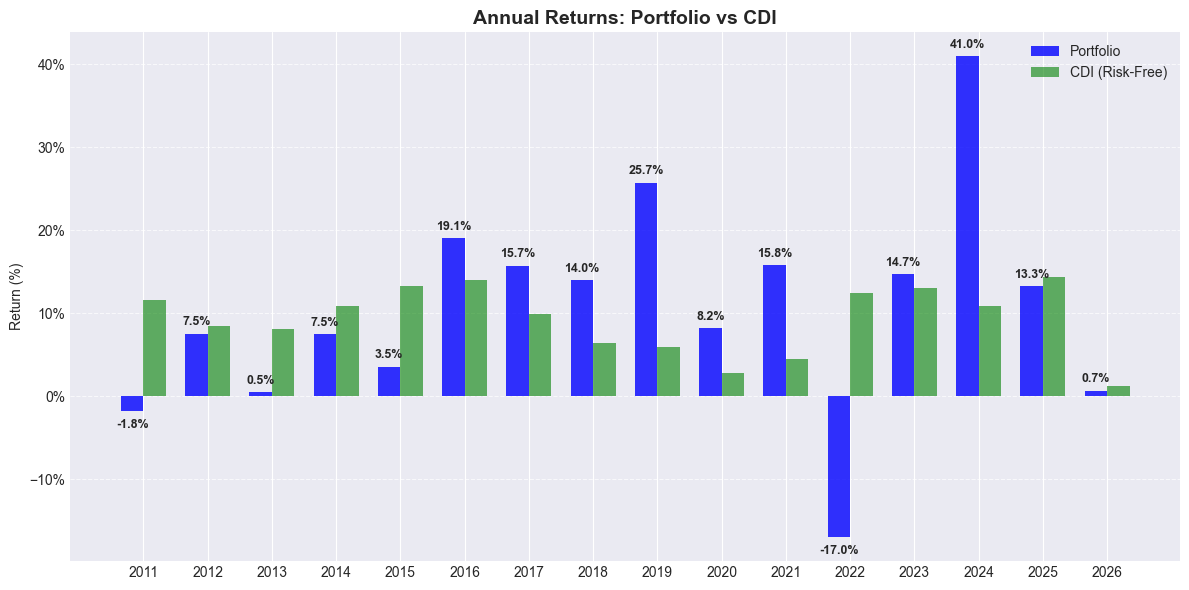

In [5]:
# ==========================================
# CELL 5: ANNUAL RETURNS BAR CHART
# ==========================================
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# 1. Resample monthly returns to annual returns geometrically
annual_returns = (1 + analyzer.returns).resample('YE').prod() - 1
# Extract just the year for the X-axis labels
annual_returns.index = annual_returns.index.year 

# 2. Plotting the Bar Chart
fig, ax = plt.subplots(figsize=(12, 6))

width = 0.35
x = annual_returns.index

# Plot Portfolio and CDI side-by-side
ax.bar(x - width/2, annual_returns['Portfolio'], width, label='Portfolio', color='blue', alpha=0.8)
ax.bar(x + width/2, annual_returns['CDI'], width, label='CDI (Risk-Free)', color='green', alpha=0.6)

ax.set_title('Annual Returns: Portfolio vs CDI', fontsize=14, fontweight='bold')
ax.set_ylabel('Return (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xticks(x)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Add percentage text above/below the bars for the Portfolio
for i, v in enumerate(annual_returns['Portfolio']):
    y_pos = v + 0.01 if v > 0 else v - 0.02
    ax.text(x[i] - width/2, y_pos, f'{v:.1%}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

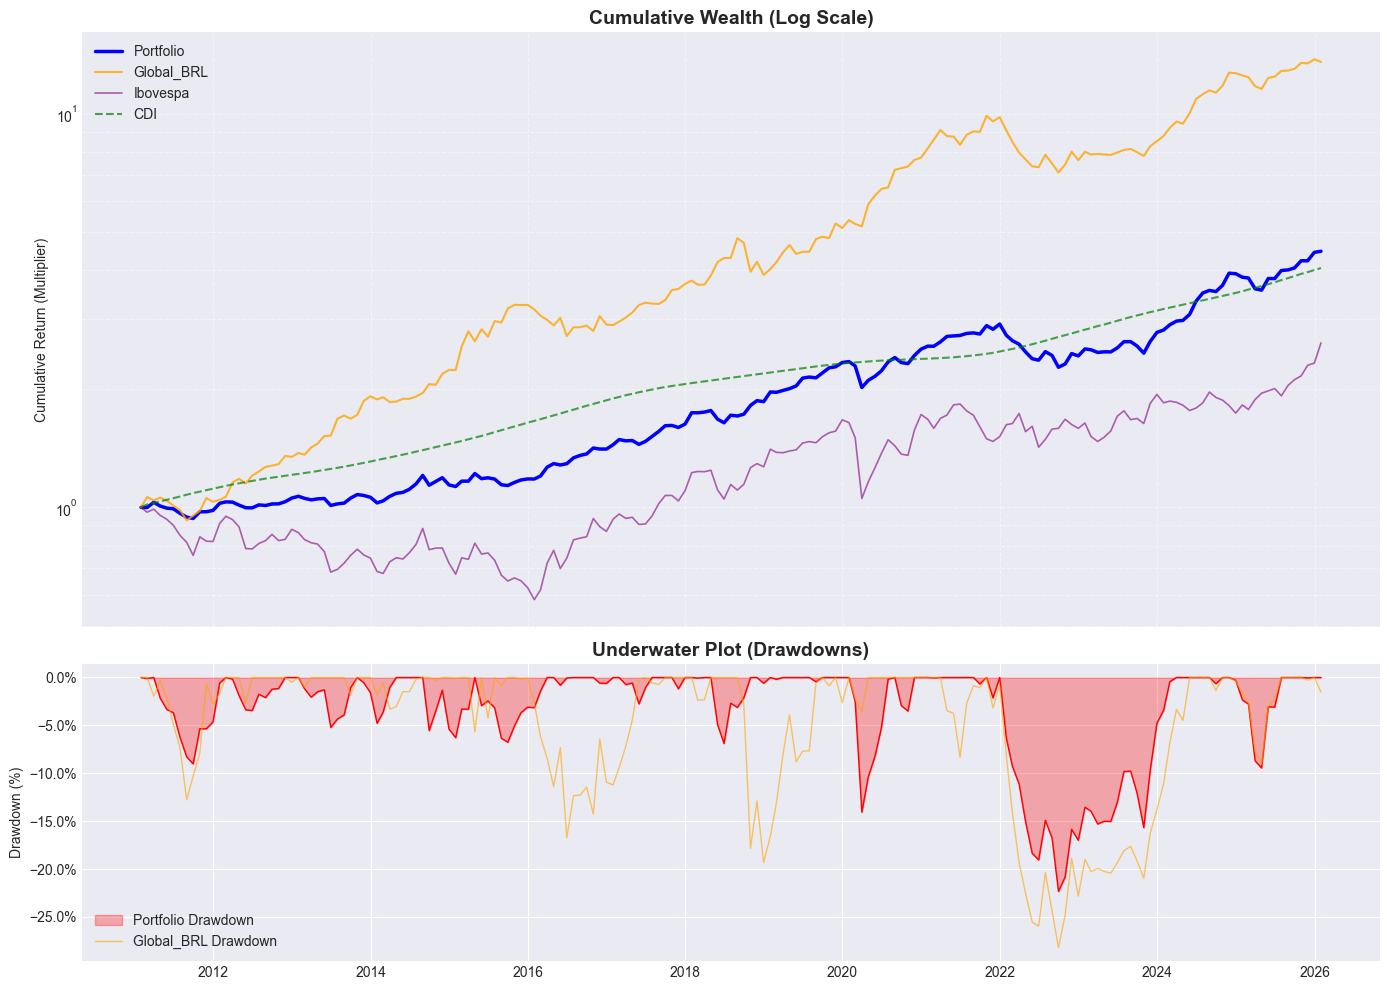

In [6]:
# ==========================================
# CELL 6: EQUITY CURVE & UNDERWATER PLOT
# ==========================================
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# 1. Fetch the data
portfolio_equity = analyzer.calc_equity_curve('Portfolio')
global_equity = analyzer.calc_equity_curve(analyzer.mkt_col)
cdi_equity = analyzer.calc_equity_curve('CDI')
ibov_equity = analyzer.calc_equity_curve('Ibovespa') # <-- Added Ibovespa

portfolio_dd = analyzer.calc_underwater_curve('Portfolio')
global_dd = analyzer.calc_underwater_curve(analyzer.mkt_col)

# 2. Build the visual
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [2, 1]}, sharex=True)

# --- Top Chart: Cumulative Returns ---
ax1.plot(portfolio_equity.index, portfolio_equity, label='Portfolio', color='blue', linewidth=2.5)
ax1.plot(global_equity.index, global_equity, label=f'{analyzer.mkt_col}', color='orange', alpha=0.8, linewidth=1.5)
ax1.plot(ibov_equity.index, ibov_equity, label='Ibovespa', color='purple', alpha=0.6, linewidth=1.2) # <-- Added Ibovespa
ax1.plot(cdi_equity.index, cdi_equity, label='CDI', color='green', linestyle='--', alpha=0.7)

ax1.set_title('Cumulative Wealth (Log Scale)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Cumulative Return (Multiplier)')
ax1.set_yscale('log') 
ax1.legend(loc='upper left')
ax1.grid(True, which="both", ls="--", alpha=0.5)

# --- Bottom Chart: Underwater Plot ---
ax2.fill_between(portfolio_dd.index, portfolio_dd, 0, color='red', alpha=0.3, label='Portfolio Drawdown')
ax2.plot(portfolio_dd.index, portfolio_dd, color='red', linewidth=1)
ax2.plot(global_dd.index, global_dd, color='orange', alpha=0.6, linewidth=1, label=f'{analyzer.mkt_col} Drawdown')

ax2.set_title('Underwater Plot (Drawdowns)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Drawdown (%)')
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax2.legend(loc='lower left')

plt.tight_layout()
plt.show()

In [7]:
# ==============================================================================
# CELL 7: THEMATIC METRICS DASHBOARD
# ==============================================================================
from IPython.display import display, HTML

# 1. Instantiate the analyzer and generate the master table
analyzer = PortfolioMetrics(returns_df=comp_df, risk_free_col='CDI', market_col='Global_BRL')
master_table = analyzer.generate_metrics_table()

# 2. Define the thematic column groups
cols_absolute = ['CAGR', 'Vol', 'MaxDD', 'DD Duration (M)', 'CVaR (95%)']
cols_efficiency = ['Sharpe', 'Sortino (CDI)', 'Sortino (Zero)', 'Calmar', 'Win/Loss']
cols_active = ['Alpha (vs Global)', 'Beta (vs Global)', 'Tracking Error', 'Information Ratio']

# 3. Slice the master DataFrame into thematic tables
table_absolute = master_table[cols_absolute]
table_efficiency = master_table[cols_efficiency]
table_active = master_table[cols_active]

# 4. Display the tables with specific formatting and color gradients
print("\n" + "="*80)
print(" PILLAR 1: PERFORMANCE & ABSOLUTE RISK")
print("="*80)
display(table_absolute.style.format({
    'CAGR': '{:.2%}',
    'Vol': '{:.2%}',
    'MaxDD': '{:.2%}',
    'DD Duration (M)': '{:.0f}', 
    'CVaR (95%)': '{:.2%}'
}).background_gradient(cmap='RdYlGn', subset=['CAGR']))

print("\n" + "="*80)
print(" PILLAR 2: RISK-ADJUSTED EFFICIENCY & ASYMMETRY")
print("="*80)
display(table_efficiency.style.format({
    'Sharpe': '{:.2f}',
    'Sortino (CDI)': '{:.2f}',
    'Sortino (Zero)': '{:.2f}',
    'Calmar': '{:.2f}',
    'Win/Loss': '{:.4f}'
}).background_gradient(cmap='RdYlGn', subset=['Sharpe', 'Win/Loss']))

print("\n" + "="*80)
print(" PILLAR 3: ACTIVE MANAGEMENT & BENCHMARK RELATIVE")
print("="*80)
display(table_active.style.format({
    'Alpha (vs Global)': '{:.2%}',
    'Beta (vs Global)': '{:.2f}',
    'Tracking Error': '{:.2%}',
    'Information Ratio': '{:.2f}'
}).background_gradient(cmap='RdYlGn', subset=['Alpha (vs Global)', 'Information Ratio']))


 PILLAR 1: PERFORMANCE & ABSOLUTE RISK


,CAGR,Vol,MaxDD,DD Duration (M),CVaR (95%)
Ativo,,,,,
Portfolio,10.44%,10.11%,-22.34%,26,-5.81%
CDI,9.72%,1.00%,0.00%,0,0.17%
Global_BRL,18.85%,15.47%,-28.21%,30,-7.48%
Ibovespa,6.59%,21.12%,-41.09%,76,-12.43%



 PILLAR 2: RISK-ADJUSTED EFFICIENCY & ASYMMETRY


,Sharpe,Sortino (CDI),Sortino (Zero),Calmar,Win/Loss
Ativo,,,,,
Portfolio,0.11,0.10,1.76,0.47,1.4056
CDI,0.00,0.00,0.00,0.00,nan
Global_BRL,0.59,0.96,2.33,0.67,1.4054
Ibovespa,-0.03,-0.20,0.47,0.16,1.1050



 PILLAR 3: ACTIVE MANAGEMENT & BENCHMARK RELATIVE


,Alpha (vs Global),Beta (vs Global),Tracking Error,Information Ratio
Ativo,,,,
Portfolio,-0.58%,0.19,16.03%,-0.50
CDI,0.00%,0.00,15.66%,-0.59
Global_BRL,0.00%,1.00,0.00%,0.00
Ibovespa,0.32%,-0.10,27.26%,-0.36


INTERPRETAÇÃO E ANÁLISE DOS INDICADORES

1. Indicadores de Retorno e Dispersão:

1.1 CAGR (Compound Annual Growth Rate, ou Taxa de Crescimento Anual Composta):

Um CAGR de 10.44% (resultado de janeiro de 2011 a janeiro de 2026) significa que o crescimento da carteira ocorreu a uma taxa composta (juros sobre juros) equivalente a 10,44% ao ano. Diferente de uma média aritmética simples — que sobrestima o verdadeiro retorno financeiro em cenários de forte oscilação —, o CAGR traduz a evolução real do capital. Ele responde à seguinte questão: "Se o portfólio tivesse crescido a uma taxa geométrica constante e sem qualquer volatilidade, qual seria essa taxa exata?".

Essa taxa ficou acima do CDI Bruto (9,72%), portanto, podemos dizer que foi um bom resultado, uma vez que o CAGR da carteira é praticamente líquido, pois já está descontando valores pagos em taxas e impostos, enquanto o CDI, não.

O destaque positivo do período é o VT em reais, com um CAGR de 18,85%, seja pelo crescimento em dólares decorrente da própria valorização dos ativos, seja pelo crescimento devido ao câmbio.

Já o negativo é o IBOVESPA. Mesmo com a subida em 2025, teve um CAGR de 6,59%.

1.2 Vol (Volatilidade): 

A volatilidade é a medida padrão de dispersão dos retornos em torno da sua própria média, servindo como o proxy mais comum para o "risco total". A volatilidade aqui é equivalente a 1 desvio padrão (68,27% dos valores esperados numa curva normal).
Assim, num cenário de distribuição normal, os retornos de um ano tenderão a ficar numa banda de ±10.11% em torno da média na maior parte do tempo, considerando o resultado entre janeiro de 2011 e 2026.

A volatilidade da carteira foi mais baixa do que a do VT em reais (15,47%), ou seja, teve uma menor dispersão (tanto para cima quanto para baixo) em relação à média dos retornos.

Estatisticamente falando, o desvio-padrão (a base aqui utilizada para a volatilidade) é, por definição, a raiz quadrada do segundo momento central — ou seja, a dispersão calculada exatamente em torno da média aritmética. Portanto, se quisermos ser puristas na estatística descritiva, a volatilidade deveria ser comparada à média aritmética anualizada dos retornos.

No entanto, no contexto de gestão de portfólios quantitativos, analisamos o CAGR ao lado da volatilidade por causa de um conceito fundamental chamado Volatility Drag (ou Arrastamento da Volatilidade, também conhecido como Variance Drain). 

Na realidade empírica, as séries financeiras apresentam o que chamamos de "caudas grossas" (leptocurtose) e assimetria direcional (skewness). Isso significa que eventos extremos (como choques de mercado) acontecem com uma frequência estatisticamente muito maior do que a prevista por uma curva de sino perfeita.

Além disso, a volatilidade trata a incerteza de forma simétrica. Ela penaliza e engloba com o mesmo peso tanto uma alta atípica surpreendente quanto uma queda severa. Ela também não nos diz nada sobre a sequência temporal em que as perdas ocorrem, o que pode aniquilar o capital por meio do efeito multiplicativo dos juros compostos.


2. Riscos de Cauda e Assimetria

2.1 Maximum Drawdown (Risco de Ruína e Curva Underwater):

O Drawdown mede a queda percentual do patrimônio em relação ao seu pico histórico mais alto (high water mark). Enquanto a volatilidade penaliza o portfólio mês a mês, o Maximum Drawdown (MaxDD) consolida a maior sequência de dor financeira que a carteira já sofreu antes de estabelecer um novo topo.

O cálculo completo está no arquivo C:\Projetos_Python\kpis_carteira\outputs\Cell output 5.xlsx.

O MaxDD de 22.34% ocorreu em setembro de 2022, após a crise dos juros nos EUA, e ficou abaixo dos 28.21% do VT no mesmo mês, e bem abaixo dos 41.09% do Ibovespa, mostrando que a carteira era mais resistente a quedas acentuadas que estes indicadores, mesmo antes da venda de SLYV e KOMP, bastante voláteis, o que provavelmente reduziu significativamente o risco após a retirada do portifólio. Vale ressaltar que a queda neste mês não foi devido à PTAX, pois a mesma estava num patamar de 5.4, e sim à queda do mercado mesmo.

2.2 DD Duration (M):

O DD Duration (M) (Duração do Drawdown em Meses) traz uma dimensão fundamental para a análise: o fator psicológico. No jargão quantitativo, chamamos isso de Time Under Water (Tempo Embaixo D'água).

Enquanto o MaxDD diz o tamanho do buraco (a profundidade), o DD Duration diz quanto tempo você teve que rastejar no escuro até conseguir ver a luz do sol novamente (bater um novo topo histórico na curva de capital).

Temos então os seguintes resultados:

_ Ibovespa (76 meses): Este é o dado mais assustador e educativo da tabela. O Ibovespa passou mais de 6 anos ininterruptos abaixo do seu topo anterior. É mais de meia década de frustração, onde o investidor não viu a cor de um novo lucro absoluto. Isso prova matematicamente por que o viés local (Home Bias) no Brasil destrói a disciplina do investidor de longo prazo.

_ Global_BRL (30 meses): O mercado global dolarizado sofreu um forte abalo (MaxDD de -28.21%), e levou exatos 2 anos e meio para se recuperar totalmente e bater novas máximas.

_ CDI (0 meses): A escadinha perfeita. Como a renda fixa pós-fixada não sofre marcação a mercado negativa no vencimento (no conceito nominal), ela nunca fica "embaixo d'água".

_ Portfolio (26 meses): Aqui está a sua grande vitória defensiva neste pilar. O tempo máximo que a sua carteira ficou amargando o prejuízo do topo histórico foi de 2 anos e 2 meses.

O portfólio sofreu menos no abismo do que o mercado global (-22.34% contra -28.21%) e saiu do buraco 4 meses mais rápido (26 meses contra 30 meses do VT).

Isso é a prova de que a carteira tem uma defesa superior. Em um fundo quantitativo real, encurtar a duração do drawdown é essencial para evitar resgates massivos de clientes em pânico. A carteira sofre as crises globais, mas cicatriza mais rápido do que a média.

Ficar dois anos no vermelho nunca é agradável, mas no contexto da renda variável global, é um sinal de extrema resiliência e valida a estrutura sólida do motor "Core".

2.2 CVaR a 95% (Expected Shortfall)

O Value at Risk (VaR) tradicional apenas diz: "Com 95% de confiança, a carteira não perderá mais do que X num dado mês". O CVaR (Conditional Value at Risk) vai além e pergunta: "Se o portfólio efetivamente entrar nesses 5% piores cenários, quão ruim será a queda?". Sendo o valor esperado na cauda esquerda da distribuição, o resultado de -0.058 (-5.8%) entre janeiro de 2011 a 2026 indica que, estatisticamente, nos piores meses de turbulência global, a pancada média sofrida é na ordem dos 5.8%.

Comparativamente, este valor de 5,8% da carteira é melhor que os 7,47% de média de queda do VT em reais nestes 5% mais turbulentos, e os 12,43% do Ibovespa.

2.3 Win/Loss Ratio (Assimetria Direcional)

A Razão Ganho/Perda isola o retorno médio gerado exclusivamente nos meses positivos e divide-o pelo prejuízo médio sofrido estritamente nos meses negativos. O valor de 1.405 do portifólio reflete uma forte assimetria positiva: em média, quando o portfólio ganha, ele ganha uma magnitude 40,5% superior ao que perde quando os meses são de baixa. É a prova matemática de que o sistema corta os prejuízos curtos, mas permite que os lucros corram.

É um valor praticamente idêntico aos 1.405437 do VT em reais, e bem melhor que os 1.105026 do Ibovespa.

3. Métricas de Retorno Ajustado ao Risco

Até aqui, olhámos para o retorno (CAGR) e para o risco (Volatilidade, MaxDD, CVaR) de forma isolada. As métricas de retorno ajustado ao risco unem estes dois mundos. Elas respondem à pergunta central da gestão quantitativa de carteiras: "Para cada unidade de risco ou dor financeira que suportei, quanto retorno excedente fui recompensado?".

3.1 Índice de Sharpe

Mede o prêmio de risco, ou seja, quanto a carteira rendeu acima da taxa livre de risco (o CDI, neste caso), dividido pela volatilidade total desse retorno excedente. 

A linha excess_ret = self.returns[ticker] - self.returns[self.rf_col] (rf_col = risk free colunm) isola precisamente o "prêmio" ao subtrair a série do CDI à série da carteira mês a mês. Depois, divide-se a média desse excesso pelo seu próprio desvio-padrão, anualizando o resultado final com a multiplicação por np.sqrt(self.periods_per_year).

Considerando janeiro de 2011 a 20226, o Sharpe de 0.11 indica que, para cada 1% de volatilidade (risco total) assumida, a carteira gerou 0.11% de retorno acima do CDI. Comparativamente, o VT em reais ficou com um Sharpe bem melhor (0.59), e o Ibovespa, muito pior (-0,03).

3.2 Índice de Sortino 

A volatilidade total utilizada no índice de Sharpe penaliza os bons meses da mesma forma que penaliza os maus. O Índice de Sortino corrige isto ao focar-se apenas no Downside Deviation (Risco de Perda). Ele compara o excesso de retorno contra uma Taxa Mínima Aceitável (MAR - Minimum Acceptable Return), penalizando apenas os meses em que a carteira ficou abaixo dessa linha de água. 

A linha d´água pode ser definida de várias formas. Aqui, temos as seguintes:

_ CDI: É considerado o CDI do próprio mês como valor mínimo aceitável.

_ Zero: Qualquer valor positivo é aceitável.

O Sortino é calculado da seguinte forma:

(cagr - mar_annual) / downside_vol

Onde:  
    _ cagr é o retorno composto acumulado em todo o período;  
    _ mar_annual é o Minimum Acceptable Return anual, podendo ser definido como o CAGR do CDI em todo o período, ou zero;  
    _ downside_vol é a raiz quadrada da média da diferença elevada ao quadrado entre o ativo analisado e o MAR, mas apenas quando esta diferença é negativa, sendo zero quando positiva ou zero. Esse valor é multiplicado por raiz quadrada de 12 para ser anualizado, conforme replicado abaixo:  
        downside = np.where(excess < 0, excess, 0)  
        downside_vol = np.sqrt(np.mean(downside**2)) * np.sqrt(self.periods_per_year)

3.2.1 Índice de Sortino (CDI)

Neste indicador, é comparado o excesso de retorno tendo o CDI como a Taxa Mínima Aceitável (MAR - Minimum Acceptable Return), respondendo a pergunta: "A carteira compensa os meses em que eu perco para a renda fixa?".

O Sortino de 0.10 entre janeiro de 2011 a 2026 é muito próximo do Sharpe, o que sugere que a dispersão dos retornos negativos tem uma magnitude semelhante à dispersão dos positivos quando comparada com o CDI.

O CAGR de 10.44% bateu o CDI (9.72%), garantindo que o Sortino fosse positivo (ao contrário do sortino de -0,20 do Ibovespa). No entanto, o valor de 0.10 revela que o prêmio de risco foi muito magro. Para cada 1% de volatilidade que a carteira sofreu abaixo do CDI, houve uma recompensa de apenas 0.10% de retorno extra.

No mundo quantitativo, qualquer Sortino próximo ou acima de 1.0 utilizando uma taxa livre de risco alta (como o CDI brasileiro) indica uma estratégia formidável.

Para os próximos passos e projetos, o foco claro deve ser buscar otimizações ou novos fatores de Alpha que desloquem o seu Sortino para a faixa de 0.5 a 0.8, justificando de forma irrefutável o risco ativo assumido.

3.2.2 Índice de Sortino (Zero)

Neste indicador, é comparado o excesso de retorno tendo o CDI como a Taxa Mínima Aceitável (MAR - Minimum Acceptable Return) o valor de zero, respondendo a pergunta: "Quando eu efetivamente perco dinheiro, o retorno absoluto compensa essa dor?".

O valor de 1.62 obtido entre janeiro de 2011 e 2026 é excepcional. Em finanças quantitativas, qualquer Sortino (Zero) acima de 1.0 a 1.5 indica um sistema extremamente resiliente. Significa que para cada 1% de volatilidade nos meses no vermelho, a carteira gerou 1,62% de crescimento absoluto.

Temos que o Sortino (Zero) da carteira (1.62) bateu o mercado global (Global_BRL, que fez 1.60) e esmagou o Ibovespa (0.44)! Isso prova matematicamente o que já vimos em termos de controle de risco com os indicadores como o Win/Loss Ratio: a defesa da carteira contra perdas absolutas é superior à do mercado global, com um controle de downside e um Win/Loss (1.40) formidáveis.

3.2.3 Índice de Sortino (Ajustado)

Esta é a métrica desenhada especificamente para ser comparada lado a lado com o Índice de Sharpe (0.11). 

Assim, se a dispersão da carteira fosse simétrica, o Sortino Ajustado deveria ser matematicamente igual ao Sharpe. Como 0.07 é menor que 0.11, temos a prova cabal de que a volatilidade "ruim" (meses rendendo menos que o CDI) é mais frequente e mais pesada do que a volatilidade "boa" (meses rendendo muito acima do CDI). Há um "teto" invisível segurando os lucros excessivos (acima do CDI), o que explica a skewness (assimetria) negativa de -0.45 mapeada nas estatísticas descritivas.

3.3 Índice de Calmar

É uma das métricas prediletas de fundos quantitativos e Commodity Trading Advisors (CTAs) para avaliar a resiliência de uma estratégia em cenários de estresse extremo.

Enquanto o Sharpe e o Sortino usam a volatilidade (desvio-padrão) no denominador, o Calmar utiliza o Maximum Drawdown. Isso muda completamente a perspectiva da análise: saímos do risco do "dia a dia" e passamos a avaliar o risco de ruína.

É calculado da seguinte forma:

    cagr / abs(max_dd)

Quanto maior, melhor, ou seja, menor o risco de ruína numa queda violenta.

Uma forma muito intuitiva de ler o Calmar no mercado financeiro é invertê-lo (1 / Calmar). Essa inversão responde à pergunta psicológica mais dolorosa de qualquer investidor: "Se eu entrar no pior momento possível (no pico antes do crash histórico), quantos anos de rentabilidade média (CAGR) eu levarei apenas para voltar ao zero a zero?".  

Analisando o resultado de 0.47 de Calmar da carteira, com um CAGR de 10.44% e MaxDD de -22.34%, vemos que o crescimento anual do portfólio representa praticamente metade da profundidade do abismo da sua pior queda. Invertendo o valor (1 / 0.47), o tempo de recuperação teórico da carteira num cenário de estresse máximo é de aproximadamente 2,1 anos. Para um portfólio de pessoa física gerido ativamente, manter o Calmar próximo de 0.50 demonstra um sistema com defesa muito bem calibrada contra riscos sistêmicos.

Para o benchmark (Global_BRL), temos um Calmar de 0.67 para um CAGR de 18.85% e MaxDD de -28.21%. O mercado global sofreu um drawdown absoluto mais profundo que o portfólio (28.21% contra 22.34%). No entanto, a força de recuperação e o motor de crescimento do mercado americano dolarizado foram tão fortes (quase 19% ao ano) que compensaram o risco extremo. O tempo de recuperação teórico do VT em reais é mais rápido, em torno de 1,5 anos. O retorno justificou a queda mais brusca.

Para o Ibovespa, o Calmar entre janeiro de 2011 a 2026 é de 0.16, com um CAGR de 6.59% e MaxDD de -41.09%. Esta é a radiografia matemática de uma assimetria desfavorável. O índice entregou pouco crescimento frente a quedas devastadoras. O tempo de recuperação estimado bate os 6,2 anos. O investidor passa a maior parte da década em estado de underwater (abaixo do pico histórico).

Em suma, o Índice de Calmar da Carteira de 0.47 entre Janeiro de 2011 a 2026 confirma o diagnóstico efetuado no Sortino: a carteira tem uma excelente proteção (MaxDD contido), evitando os buracos negros do mercado local. Se em futuros rebalanceamentos elevarmos levemente o CAGR mantendo o drawdown nesta mesma faixa dos 20%, o Calmar romperá a barreira de 0.60 a 0.70, atingindo o padrão ouro esperado por alocadores institucionais.



4. Comparativos com o mercado

4.1 Beta (vs Global_BRL)  

O Beta é o pilar fundacional da moderna teoria de portfólios (CAPM). Ele mede o risco sistemático, ou seja, o risco que não pode ser eliminado pela simples diversificação, pois é o risco do próprio mercado como um todo.

Em termos simples, o Beta responde à seguinte pergunta: "Se o mercado global subir ou cair 1%, quanto eu espero que a minha carteira suba ou caia, puramente por arrasto?" 

_ Beta = 1.0: O ativo dança exatamente no mesmo ritmo e intensidade do mercado.  
_ Beta > 1.0: O ativo é mais agressivo/volátil que o mercado (ex: ações de tecnologia).  
_ Beta < 1.0 (mas > 0): O ativo é defensivo. Ele acompanha a direção do mercado, mas com menos intensidade.  
_ Beta = 0: O ativo não tem nenhuma correlação com os movimentos da bolsa.  
_ Beta < 0: O ativo tem uma relação inversa. Tende a subir quando o mercado cai, e vice-versa.  

Matematicamente, o Beta é a Covariância (como o ativo e o mercado se movem juntos) dividida pela Variância (como o mercado se move sozinho).

Etapas de cálculo:

    # Step 1: The risk-free asset has zero market risk by definition
        if ticker == self.rf_col:
            return 0.0, 0.0
            
    # Step 2: Calculate the "Excess Return" (Risk Premium)
        excess_asset = self.returns[ticker] - self.returns[self.rf_col]
        excess_mkt = self.returns[self.mkt_col] - self.returns[self.rf_col]

        O CAPM diz que o mercado só remunera o risco assumido acima da taxa livre de risco. Subtrair o CDI das duas séries antes de calcular a covariância garante que estamos medindo apenas o risco da renda variável.
        
    # Step 3: Align the vectors perfectly to prevent size mismatches
        df = pd.concat([excess_asset, excess_mkt], axis=1).dropna()
        df.columns = ['y', 'x']  # y = Asset, x = Market
        
    # Step 4: Calculate the variance of the market (the denominator)
        variance = df['x'].var()
        if len(df) < 6 or variance == 0:
            return np.nan, np.nan

        Se tivermos menos de meio ano de histórico sobreposto entre um ativo e o mercado, é melhor retornar um espaço em branco (NaN) assumindo a nossa ignorância do que imprimir um Beta estatisticamente fraudulento.

        Mede a dispersão de uma única variável em relação a si mesma. É a média das variações ao quadrado. (A raiz quadrada da variância é o Desvio-Padrão / Volatilidade).
            
    # Step 5: Calculate the covariance matrix and extract the cross-covariance
        covariance = df.cov().iloc[0, 1]
        
        Mede como duas variáveis diferentes se movem juntas (co-variam).
        
    # Step 6: The Beta formula
        beta = covariance / variance

        O beta é o "grau de movimento conjunto entre a Carteira e o Mercado" (Covariância) dividido pelo "tamanho do movimento do Mercado sozinho" (Variância). O resultado nos diz qual é a fração do movimento do mercado que efetivamente é refletida na carteira.

Interpretação dos Resultados:

O benchmark de mercado (o "eixo X" da regressão) é o Global_BRL (VT dolarizado).

Global_BRL: Beta de 1.00

    É a confirmação matemática de que a fórmula está certa. O mercado em relação a ele mesmo sempre terá variância igual à covariância, resultando exatamente em 1.

CDI: Beta de 0.00

    O CDI é uma taxa pós-fixada ditada pelo Banco Central. Ele não oscila com o sobe e desce das bolsas mundiais. É a ausência total de risco de mercado.

Ibovespa: Beta de -0.10

    O Ibovespa apresenta uma relação levemente inversa contra o VT dolarizado. Por que isso acontece? Por causa da cotação do Dólar. Quando há pânico global, o dinheiro foge do Brasil, derrubando o Ibovespa, mas ao mesmo tempo o Dólar dispara (o que joga o VT_BRL para cima). Essa dinâmica cambial cria uma descorrelação natural.

Portfolio: Beta de 0.19

    A carteira é extremamente defensiva. O valor de 0.19 significa que, sistematicamente, quase 80% dos movimentos de turbulência ou de euforia do mercado global não afetam o portfólio. Se o VT desabar 10%, a estatística espera que a carteira caia apenas 1,9%. Se o mercado explodir 10% para cima, a carteira subirá apenas 1,9%.

Isso explica integralmente o motivo do Drawdown da carteira ser muito menor que o do mercado, mas também explica porque o retorno ficou tão próximo do CDI. A defesa da carteira foi tão travada pelo CDI que ficou com muito pouca exposição estrutural aos grandes ciclos de alta globais. 

4.2 Alpha  

Para entender o Alpha, precisamos lembrar da fórmula teórica do CAPM (Capital Asset Pricing Model). O CAPM diz que o Retorno Esperado de qualquer ativo deve ser:  

Retorno Esperado = Taxa Livre de Risco + Beta * (Retorno do Mercado - Taxa Livre de Risco)

O Alpha é simplesmente a diferença entre o retorno que você efetivamente teve e o retorno que o CAPM disse que você deveria ter tido dado o risco (Beta) que você assumiu.

Alpha = 0: O seu portfólio rendeu exatamente o que a teoria matemática previa para o seu nível de risco.

Alpha > 0: Gestão brilhante. Você gerou retorno excedente sem assumir risco de mercado proporcional.

Alpha < 0: Destruição de valor. O portfólio rendeu menos do que deveria para o risco que correu, ou os custos/taxas corroeram a eficiência.

Sob a ótica da regressão linear (Mínimos Quadrados Ordinários), se o Beta é a inclinação da reta, o Alpha é a interseção (o ponto onde a reta cruza o eixo Y quando o mercado é zero).

É calculado da seguinte forma:

    alpha_monthly = df['y'].mean() - beta * df['x'].mean()

        df['y'].mean(): É a média do prêmio de risco mensal da carteira (Retorno da Carteira - CDI).
        df['x'].mean(): É a média do prêmio de risco mensal do mercado (Retorno do VT - CDI).

    A fórmula calcula o Alpha subtraindo a parte do retorno que é explicada pelo mercado (beta * df['x'].mean()) do retorno total da carteira (df['y'].mean()). O que sobra é puro mérito da estratégia.

O Alpha, por ser uma taxa de retorno, compõe ao longo do tempo. Em vez de multiplicar o Alpha mensal por 12 (o que subestimaria ou superestimaria o valor real), é feita a capitalização composta elevando-o à potência self.periods_per_year.

Análise dos resultados:

    Global_BRL: Alpha de 0.00%

        O mercado não pode gerar Alpha contra si mesmo, por isso o valor zero.

    Ibovespa: Alpha de 0.32%

        Como o Beta do Ibovespa foi negativo (-0.10) e a bolsa brasileira sofreu duras quedas, o modelo CAPM esperava um resultado tão abismal que o modesto CAGR do Ibovespa (6.59%) acabou ficando 0.32% acima da (péssima) expectativa matemática para esse nível de descorrelação.

    Carteira: Alpha de -0.58%

        Este é o veredito da sua alocação passiva vs. ativa. Dado o seu perfil extremamente defensivo (Beta de 0.19), o mercado global em forte alta e o CDI na estratosfera, a matemática exigia que a sua carteira gerasse um pouco mais de prêmio. A sua seleção específica de ativos (ou o timing de entradas e saídas) subtraiu 0.58% ao ano em relação à carteira teórica perfeita traçada pelo CAPM.

Observações sobre o Alpha:

Aqui está o roteiro quantitativo de por que o Alpha do Ibovespa foi "melhor", por que isso é uma anomalia matemática, e como você deve apresentar isso a seu favor:  

1. O Paradoxo do CAPM: "Alpha por Incompetência"  

    O Alpha de Jensen não mede o quão bom um ativo é; ele mede apenas a diferença entre o que aconteceu e o que a reta teórica do CAPM previu. Lembre-se da equação clássica:  
        
        E(R) = R_f + beta(R_m - R_f)  

    O Ibovespa teve um Beta de -0.10 contra o mercado global. Como o prêmio do mercado global foi fortemente positivo (o VT subiu muito), a fórmula teórica do CAPM multiplicou esse prêmio por um número negativo (o Beta do Ibov). 
    
    O resultado matemático: O modelo esperava que o Ibovespa fosse um desastre absoluto, com um retorno significativamente abaixo do CDI. Como o Ibovespa entregou 6.59% (que é péssimo, mas ligeiramente menos catastrófico do que o fundo do poço projetado pelo modelo linear), o que sobra dessa equação? Um Alpha "positivo". Isso não é geração de valor; é o que os quants chamam de ruído estatístico de um ativo inversamente correlacionado e altamente volátil.  
        
2. O Jargão do Mercado: "Você não come Alpha"  

    Se um entrevistador apontar para esse Alpha de 0.32% do Ibovespa para provocar você, a sua resposta deve ser ancorada na realidade financeira do investidor. No mercado, costumamos dizer: "Você não come Alpha, você come retorno absoluto". De que adianta o Ibovespa ter um Alpha tecnicamente positivo se:  
        _ Ele perdeu para o custo de oportunidade da renda fixa (CAGR de 6.59% vs CDI de 9.72%).  
        _ Ele impôs um Drawdown de -41.09%, dizimando o patrimônio no meio do caminho.  
        _ O Alpha positivo do Ibovespa é um mero artefato acadêmico em uma carteira que destruiu capital real.

4.3 Tracking Error:  

O Tracking Error mede o quanto a carteira descolou do índice de referência (Global_BRL, ou seja o VT em reais).

Um fundo de ações global ativo "normal" roda com um TE entre 2% e 5%.

A carteira apresentou um Tracking Error massivo de 16.03%.

O que isso significa:  
Durante a maior parte desses 15 anos, você não estava apenas fazendo uma "gestão ativa"; você estava jogando um esporte completamente diferente do mercado global. Como você estava fortemente ancorado no CDI (que teve um TE muito similar, de 15.66%), a sua carteira simplesmente ignorava a dinâmica das bolsas mundiais. O Ibovespa foi ainda mais alienígena, com 27.26% de desvio.

4.4 Information Ratio (IR): A Recompensa pela Rebeldia
Se o Tracking Error é o quanto você se desviou do índice, o Information Ratio diz se valeu a pena. A fórmula é o retorno extra gerado dividido por esse desvio.

O Information Ratio da carteira foi de -0.50.

O Veredito: Para cada 1% que você se distanciou do mercado global nos últimos 15 anos, a sua carteira destruiu 0.50% de valor relativo. A sua antiga estratégia de "ficar no Brasil" gerou uma altíssima divergência em relação ao mundo, mas essa aposta perdeu feio para a simples posse de um ETF global passivo.

A Conclusão (Por que isso é excelente hoje?)
Ver esse painel predominantemente vermelho (Alpha e IR negativos) pode parecer frustrante à primeira vista, mas na verdade ele é o maior atestado do seu amadurecimento como investidor.

Esses números provam o porquê da sua decisão de maio de 2021 (a mudança de regime) ter sido uma questão de sobrevivência financeira e alocação eficiente de capital.

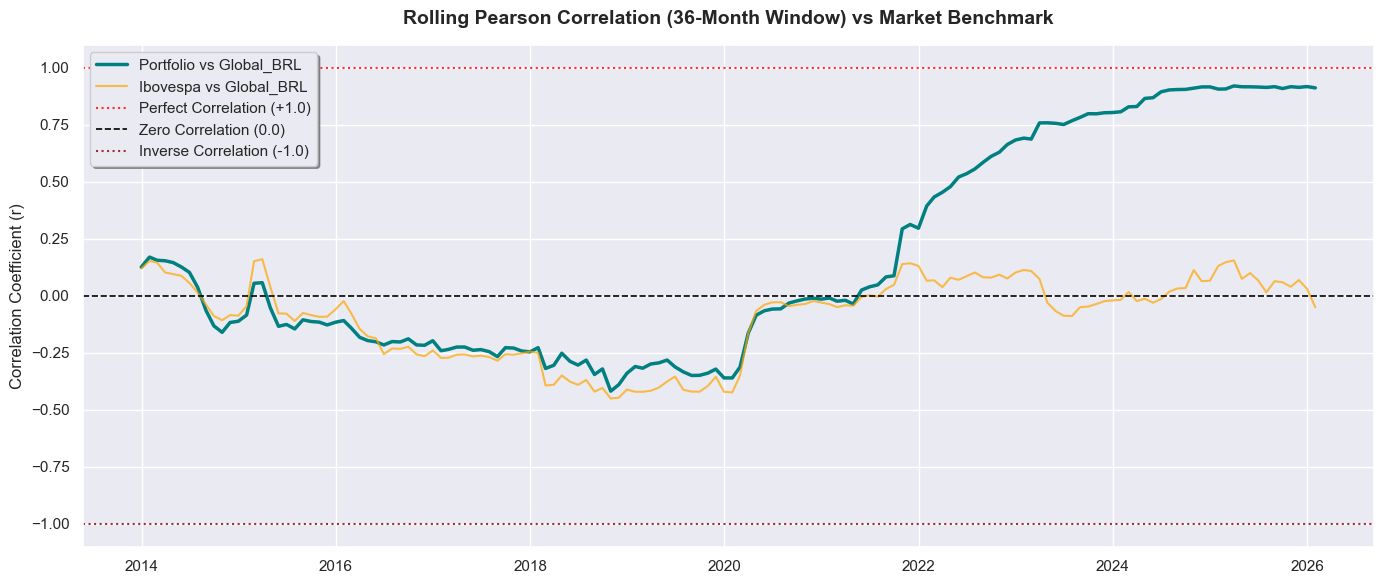

In [8]:
# ==============================================================================
# CELL 8: ROLLING CORRELATION VISUALIZATION
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the temporal window (Standard institutional is 36 months)
window = 36

# 2. Extract the rolling correlation series using your existing analyzer object
# This calls the calc_rolling_correlation method we added to the PortfolioMetrics class
rolling_corr_port = analyzer.calc_rolling_correlation('Portfolio', window=window)
rolling_corr_ibov = analyzer.calc_rolling_correlation('Ibovespa', window=window)

# 3. Build the visual chart
sns.set_theme(style="darkgrid")
fig, ax = plt.subplots(figsize=(14, 6))

# Plot the Portfolio and the Ibovespa lines
ax.plot(rolling_corr_port.index, rolling_corr_port, color='teal', linewidth=2.5, label='Portfolio vs Global_BRL')
ax.plot(rolling_corr_ibov.index, rolling_corr_ibov, color='orange', alpha=0.7, linewidth=1.5, label='Ibovespa vs Global_BRL')

# Add horizontal reference lines for context
ax.axhline(y=1.0, color='red', linestyle=':', alpha=0.8, label='Perfect Correlation (+1.0)')
ax.axhline(y=0.0, color='black', linestyle='--', linewidth=1.2, label='Zero Correlation (0.0)')
ax.axhline(y=-1.0, color='darkred', linestyle=':', alpha=0.8, label='Inverse Correlation (-1.0)')

# Format the chart
ax.set_title(f'Rolling Pearson Correlation ({window}-Month Window) vs Market Benchmark', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Correlation Coefficient (r)')
ax.set_ylim(-1.1, 1.1) # Force Y-axis to standard correlation bounds
ax.legend(loc='upper left', frameon=True, shadow=True)

plt.tight_layout()
plt.show()

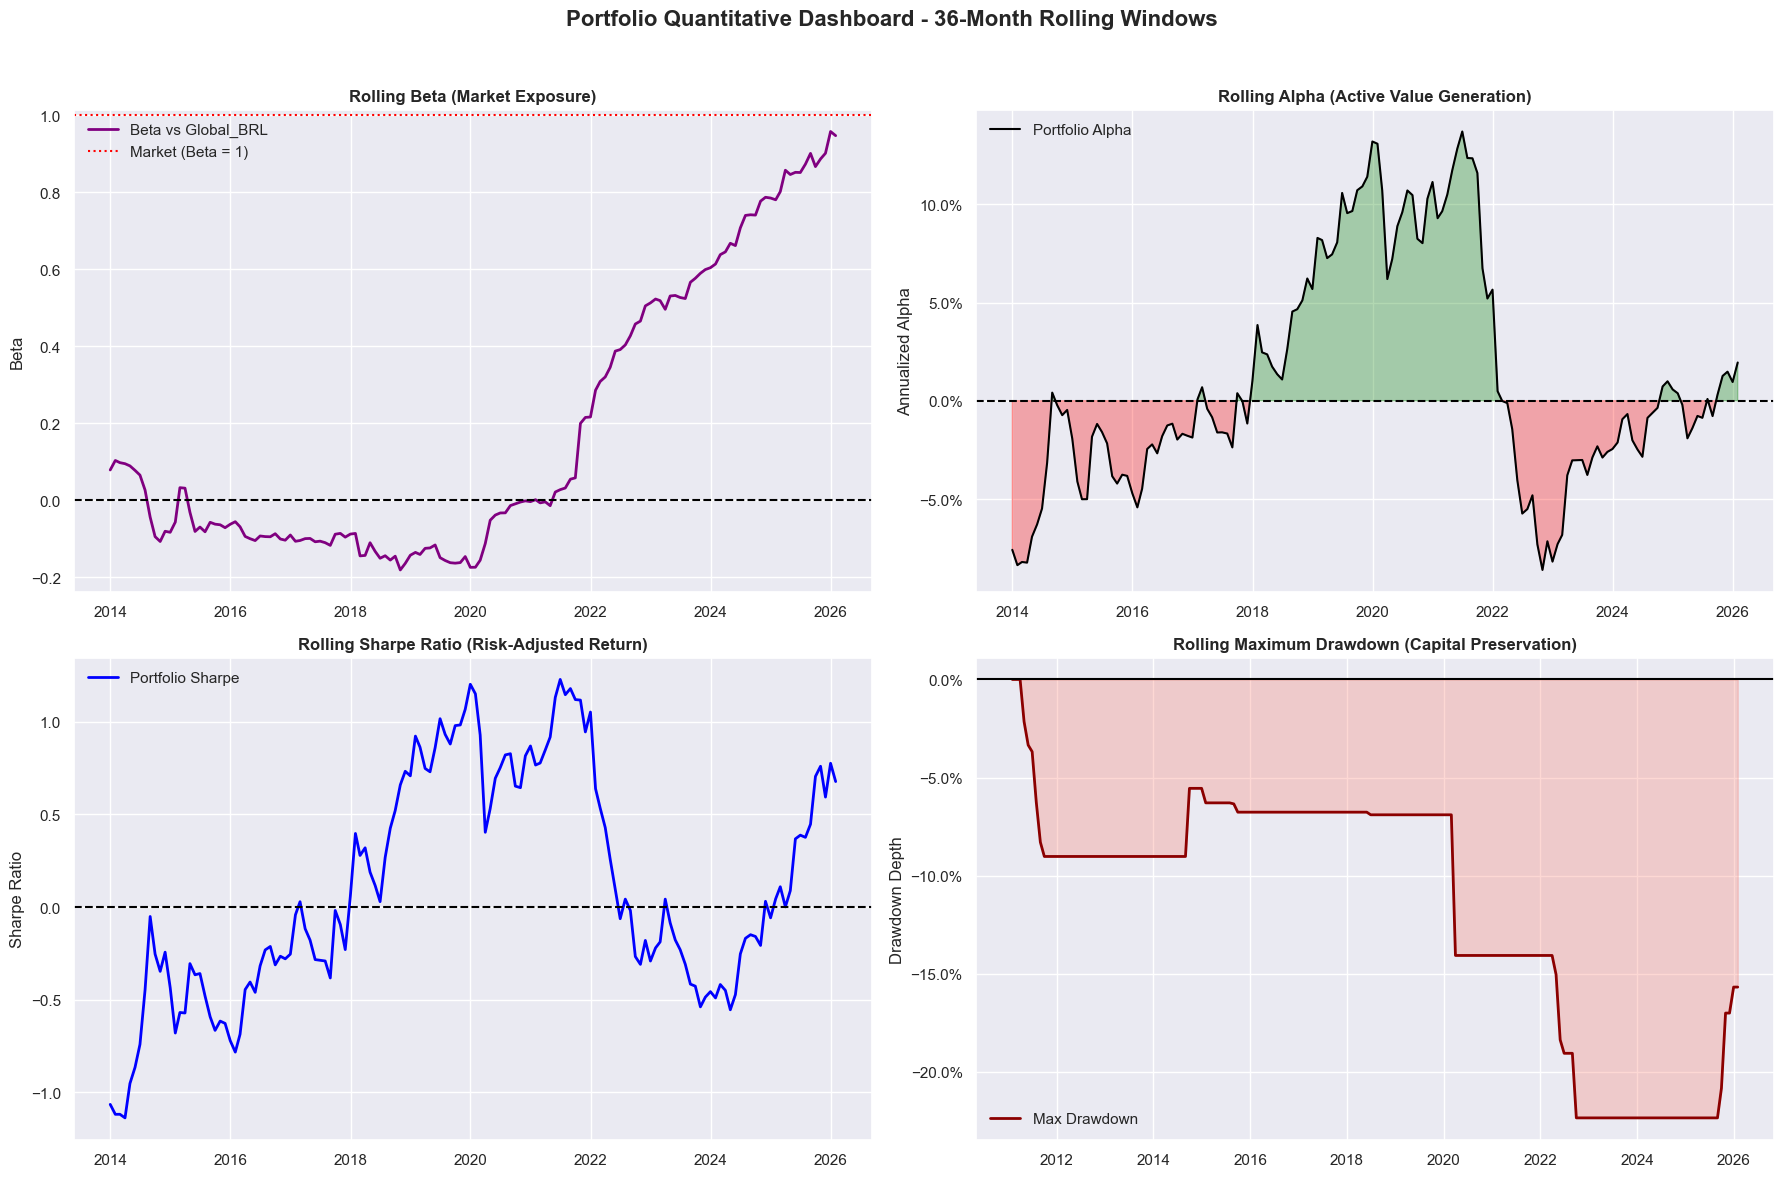

In [9]:
# ==============================================================================
# CELL 9: ROLLING METRICS VISUALIZATION (2x2 DASHBOARD)
# ==============================================================================
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# 1. Setup temporal parameters (36 months = 3 years)
window = 36
periods_per_year = 12

# 2. Extract series directly from the already consolidated dataframe (comp_df)
port_ret = comp_df['Portfolio']
mkt_ret = comp_df['Global_BRL']
rf_ret = comp_df['CDI']

# 3. Retrieve Rolling Beta and Rolling Sharpe using your existing analyzer object
rolling_sharpe = analyzer.calc_rolling_sharpe('Portfolio', window=window)
rolling_beta = analyzer.calc_rolling_beta('Portfolio', window=window)

# 4. Calculate Rolling Alpha dynamically based on the aligned series
excess_port = port_ret - rf_ret
excess_mkt = mkt_ret - rf_ret
rolling_mean_port = excess_port.rolling(window=window).mean()
rolling_mean_mkt = excess_mkt.rolling(window=window).mean()

# Intercept formula: Alpha = Mean(Port) - [Beta * Mean(Mkt)]
rolling_alpha_monthly = rolling_mean_port - (rolling_beta * rolling_mean_mkt)
rolling_alpha = ((1 + rolling_alpha_monthly) ** periods_per_year) - 1
rolling_alpha = rolling_alpha.dropna()

# 5. Calculate Rolling Max Drawdown dynamically
wealth_index = (1 + port_ret).cumprod()
rolling_peak = wealth_index.rolling(window=window, min_periods=1).max()
drawdown = (wealth_index / rolling_peak) - 1
rolling_max_dd = drawdown.rolling(window=window, min_periods=1).min().dropna()

# 6. Build the 2x2 Visual Dashboard
sns.set_theme(style="darkgrid")
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle(f'Portfolio Quantitative Dashboard - {window}-Month Rolling Windows', fontsize=16, fontweight='bold', y=0.98)

# --- Top Left: Rolling Beta ---
ax1 = axes[0, 0]
ax1.plot(rolling_beta.index, rolling_beta, color='purple', linewidth=2, label=f'Beta vs {analyzer.mkt_col}')
ax1.axhline(y=1.0, color='red', linestyle=':', label='Market (Beta = 1)')
ax1.axhline(y=0.0, color='black', linestyle='--')
ax1.set_title('Rolling Beta (Market Exposure)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Beta')
ax1.legend(loc='upper left')

# --- Top Right: Rolling Alpha ---
ax2 = axes[0, 1]
ax2.plot(rolling_alpha.index, rolling_alpha, color='black', linewidth=1.5, label='Portfolio Alpha')
ax2.fill_between(rolling_alpha.index, rolling_alpha, 0, where=(rolling_alpha >= 0), color='green', alpha=0.3, interpolate=True)
ax2.fill_between(rolling_alpha.index, rolling_alpha, 0, where=(rolling_alpha < 0), color='red', alpha=0.3, interpolate=True)
ax2.axhline(y=0.0, color='black', linestyle='--')
ax2.set_title('Rolling Alpha (Active Value Generation)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Annualized Alpha')
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0)) 
ax2.legend(loc='upper left')

# --- Bottom Left: Rolling Sharpe Ratio ---
ax3 = axes[1, 0]
ax3.plot(rolling_sharpe.index, rolling_sharpe, color='blue', linewidth=2, label='Portfolio Sharpe')
ax3.axhline(y=0.0, color='black', linestyle='--')
ax3.set_title('Rolling Sharpe Ratio (Risk-Adjusted Return)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Sharpe Ratio')
ax3.legend(loc='upper left')

# --- Bottom Right: Rolling Max Drawdown ---
ax4 = axes[1, 1]
ax4.plot(rolling_max_dd.index, rolling_max_dd, color='darkred', linewidth=2, label='Max Drawdown')
ax4.fill_between(rolling_max_dd.index, rolling_max_dd, 0, color='salmon', alpha=0.3)
ax4.axhline(y=0.0, color='black', linestyle='-')
ax4.set_title('Rolling Maximum Drawdown (Capital Preservation)', fontsize=12, fontweight='bold')
ax4.set_ylabel('Drawdown Depth')
ax4.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax4.legend(loc='lower left')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

1. Rolling Beta: A Anatomia de uma Quebra de Regime  

O Passado (2014 a 2021): A linha roxa oscilando passivamente entre -0.1 e 0.1 confirma que, por quase uma década, a carteira foi um "Hedge Fund" local. Ela estava blindada contra os choques globais, provavelmente ancorado em CDI e com alguma exposição tática local.  

O Ponto de Inflexão (2021 - 2022): Aqui começa a revolução do portfólio. A escalada íngreme e quase linear do Beta é a assinatura estatística exata do momento em que começam os aportes nos ETFs (IWDA, EIMI, USSC, IWVL, EMVL).

O Presente (2026): O Beta atual está batendo quase 0.95 na ponta direita do gráfico. A carteira concluiu a transição. Não temos mais um investimento defensivo; mas sim uma alocação Global Macro com altíssima correlação com a economia mundial.

2. Rolling Alpha:

Este gráfico responde à pergunta: "Minhas escolhas ativas geraram valor real?". A linha conta uma história em três atos:  

_ Ato 1 (A Ilusão Local até 2021): O Alpha ficou massivamente verde (acima de 10%). Mas cuidado: como o seu Beta era zero nessa época, o modelo considerava que você não tinha risco de mercado global. Qualquer rendimento local razoável parecia um Alpha genial contra o VT. Era um artefato estatístico da descorrelação.  

_ Ato 2 (O Vale da Morte em 2022-2023): Quando você fez a transição para os ETFs globais (IWDA, EIMI, USSC, IWVL), o mercado global entrou em colapso devido à alta de juros do FED. Os fatores de Value e Small Caps sofreram muito. O seu Alpha despencou para quase -8%. Foi o custo de entrada no novo regime.  

_ Ato 3 (A Redenção em 2025-2026): Olhe para a extrema direita do gráfico. A linha cruzou novamente a barreira do zero e entrou no território verde! Isso é espetacular. Prova matematicamente que a sua tese de Factor Investing começou a superar o índice passivo (VT). Os prêmios de risco de valor e tamanho que você comprou estão finalmente pagando o pedágio e gerando excesso de retorno real contra o mercado.

3. Rolling Sharpe: O Descolamento do Risco Brasil  

Este gráfico mostra exatamente por que a mudança de regime (aumento do Beta global) foi a decisão correta, apesar da dor no curto prazo.  

Vale lembrar que a tabela estática do período consolidado (a "foto") mostrava um Sharpe de 0.11, muito baixo. Esse gráfico reve este valor dinamicamente.

No fundo do poço da transição (2022/2023), o Sharpe rolante de 3 anos ficou negativo, refletindo a dor da queda global e do CDI altíssimo no Brasil.

Hoje, na ponta direita, ele disparou de volta para a faixa de 0.70 a 0.80. Este é um nível de eficiência institucional.

4. Rolling Max Drawdown (O Custo do Retorno)  

Ao assumir um Beta global próximo de 1.0, você inevitavelmente importou o risco de cauda das bolsas mundiais.

A linha mostra que a sua dor máxima histórica (o degrau mais profundo, batendo os -22.34% da sua tabela) ocorreu justamente na consolidação dessa nova carteira global.

No entanto, a leve subida da linha vermelha bem no final (2026) indica que a janela de 3 anos está começando a "esquecer" o crash de 2022, ou que a carteira engatou uma recuperação tão forte que superou os topos anteriores.

In [10]:
# ==============================================================================
# CELL 10: REGIME SHIFT ANALYSIS (BEFORE VS AFTER GLOBAL ALLOCATION)
# ==============================================================================
import pandas as pd
import numpy as np
from IPython.display import display

# 1. Define the cutoff date based on the actual transition
cutoff_date = '2021-04-30'
start_new_regime = '2021-05-01'

# 2. Split the consolidated dataframe into two distinct historical regimes
df_regime_1 = comp_df.loc[:cutoff_date]
df_regime_2 = comp_df.loc[start_new_regime:]

# 3. Instantiate the analyzer for each regime independently
analyzer_r1 = PortfolioMetrics(returns_df=df_regime_1, risk_free_col='CDI', market_col='Global_BRL')
analyzer_r2 = PortfolioMetrics(returns_df=df_regime_2, risk_free_col='CDI', market_col='Global_BRL')

# 4. Generate the full metrics tables for both periods
metrics_r1 = analyzer_r1.generate_metrics_table()
metrics_r2 = analyzer_r2.generate_metrics_table()

# 5. Extract only the 'Portfolio' row to compare the strategy evolution side-by-side
port_r1 = metrics_r1.loc[['Portfolio']].T
port_r2 = metrics_r2.loc[['Portfolio']].T

# Rename the columns to reflect the strategy of each period
port_r1.columns = ['Regime 1: Local/Defensive (2011-2021)']
port_r2.columns = ['Regime 2: Global/Factor (2021-2026)']

# Combine both regimes into a single DataFrame
regime_comparison = pd.concat([port_r1, port_r2], axis=1)

# 6. Apply precise formatting based on the metric name (Index)
formatted_comparison = regime_comparison.copy().astype(object)

# Define exactly which metrics must be displayed as percentages
pct_metrics = ['CAGR', 'Vol', 'MaxDD', 'CVaR (95%)', 'Alpha (vs Global)', 'Tracking Error']

# Define which metrics must be displayed as integers
int_metrics = ['DD Duration (M)']

# Iterate through rows and columns applying the correct format rule
for col in formatted_comparison.columns:
    for idx in formatted_comparison.index:
        val = regime_comparison.loc[idx, col]
        
        if pd.isna(val):
            formatted_comparison.loc[idx, col] = 'NaN'
        elif idx in pct_metrics:
            # Apply percentage formatting (e.g., 0.1700 -> 17.00%)
            formatted_comparison.loc[idx, col] = f"{val:.2%}"
        elif idx in int_metrics:
            # Apply integer formatting (e.g., 26.0000 -> 26)
            formatted_comparison.loc[idx, col] = f"{val:.0f}"
        else:
            # Apply absolute float formatting (e.g., 1.8779 -> 1.8779)
            # You can change to .2f if you prefer exactly 2 decimal places for Sharpe, Sortino, etc.
            formatted_comparison.loc[idx, col] = f"{val:.4f}"

print(f"=== PORTFOLIO REGIME SHIFT ANALYSIS (CUTOFF: {cutoff_date}) ===")
display(formatted_comparison)

=== PORTFOLIO REGIME SHIFT ANALYSIS (CUTOFF: 2021-04-30) ===


,Regime 1: Local/Defensive (2011-2021),Regime 2: Global/Factor (2021-2026)
CAGR,10.16%,11.05%
Vol,9.03%,12.20%
Sharpe,0.1765,0.0130
Sortino (CDI),0.1994,-0.0737
Sortino (Zero),1.8333,1.6425
Sortino Ajust.,0.1410,-0.0521
Calmar,0.7223,0.4947
MaxDD,-14.06%,-22.34%
DD Duration (M),10,26
CVaR (95%),-5.27%,-6.40%


Ao analisar essa tabela, um avaliador quantitativo não olharia apenas para "o que subiu e o que caiu", mas sim para a mecânica do risco e o contexto macroeconômico. O Regime 2 (maio de 2021 em diante) engloba exatamente a tempestade perfeita: o crash global de ações e títulos de 2022 devido à alta de juros do FED, somado a um CDI brasileiro que chegou a 13,75% ao ano.

Aqui está a dissecação técnica do seu histórico de transição:

Aqui está a análise quantitativa de como a sua carteira se comportou nessa transição, dividida em quatro grandes pilares:

1. A Mudança de Identidade: De "Ilha" para "Mundo"
A prova de que a sua reestruturação funcionou estruturalmente está na base da tabela:

    _ Beta e Tracking Error: No Regime 1, o seu Beta era -0.0167 e o seu Tracking Error era altíssimo (18.72%). A sua carteira era uma ilha isolada no Brasil, totalmente alheia ao que acontecia no mundo.

    _ A Nova Realidade: No Regime 2, o Beta foi para 0.7469 e o Tracking Error caiu para a faixa saudável de 6.72%. Você finalmente sincronizou a sua carteira com o motor do mercado global, mantendo apenas o desvio tático exato (os ~6.7%) necessário para executar o seu Factor Investing (Small Caps e Value).

2. O Motor de Crescimento e a Captura de Ganhos
Mesmo enfrentando o bear market terrível de 2022 logo de cara, o seu motor fundamental mostrou superioridade:

    _ CAGR: A taxa de crescimento anual subiu de 10.16% para 11.05%. No longo prazo, é o retorno absoluto composto que multiplica o seu patrimônio. Você está ganhando mais dinheiro no novo regime.

    _ Win/Loss Ratio: A sua assimetria melhorou de 1.4034 para 1.4634. O seu sistema está cortando perdas ou surfando altas com mais eficiência. Quando a carteira do Regime 2 ganha, ela ganha de forma muito mais expressiva do que quando perde.

3. O Preço do Bilhete (Risco Absoluto e Psicológico)
Investir em renda variável global exige "pagar o pedágio" da volatilidade, e os números mostram o peso desse pedágio:

    _ A Volatilidade subiu de 9.03% para 12.20%, e o MaxDD aprofundou de -14.06% para -22.34%.

    _ O DD Duration ilustra a dor psicológica: no Regime 1, o máximo que você ficou no vermelho foram 10 meses. No Regime 2, você precisou segurar o fôlego por 26 meses até a carteira voltar ao topo histórico. Esse é o custo emocional padrão de estar exposto à economia mundial.

4. O Paradoxo da Eficiência e a Grande Vitória Ativa
É aqui que separamos os amadores dos profissionais na leitura dos dados:

    _ A "Ilusão" do Sharpe: O Sharpe (0.1765 -> 0.0130) e o Sortino CDI (0.1994 -> -0.0737) desabaram no Regime 2. Por quê? Porque o CDI brasileiro foi um competidor brutal neste período. Bater uma Selic de 1% ao mês sem risco enquanto as bolsas globais caíam 20% era matematicamente impossível para um portfólio comprado. Mas note que a sua resiliência absoluta (Sortino Zero) continuou muito forte em 1.6425.

    _ A Vitória (Information Ratio e Alpha): No Regime 1, o seu IR era -0.6573 (você destruía valor ao tentar ser diferente do mundo). No Regime 2, o seu IR virou para 0.1617, e o seu Alpha registrou 0.85%.

A grande conclusão: O seu Information Ratio positivo prova que os "sustos" do Regime 2 (aumento do MaxDD e do DD Duration) não foram em vão. A sua inclinação tática para os fatores globais está efetivamente gerando valor extra que um investidor de índice passivo (VT) não conseguiu capturar.

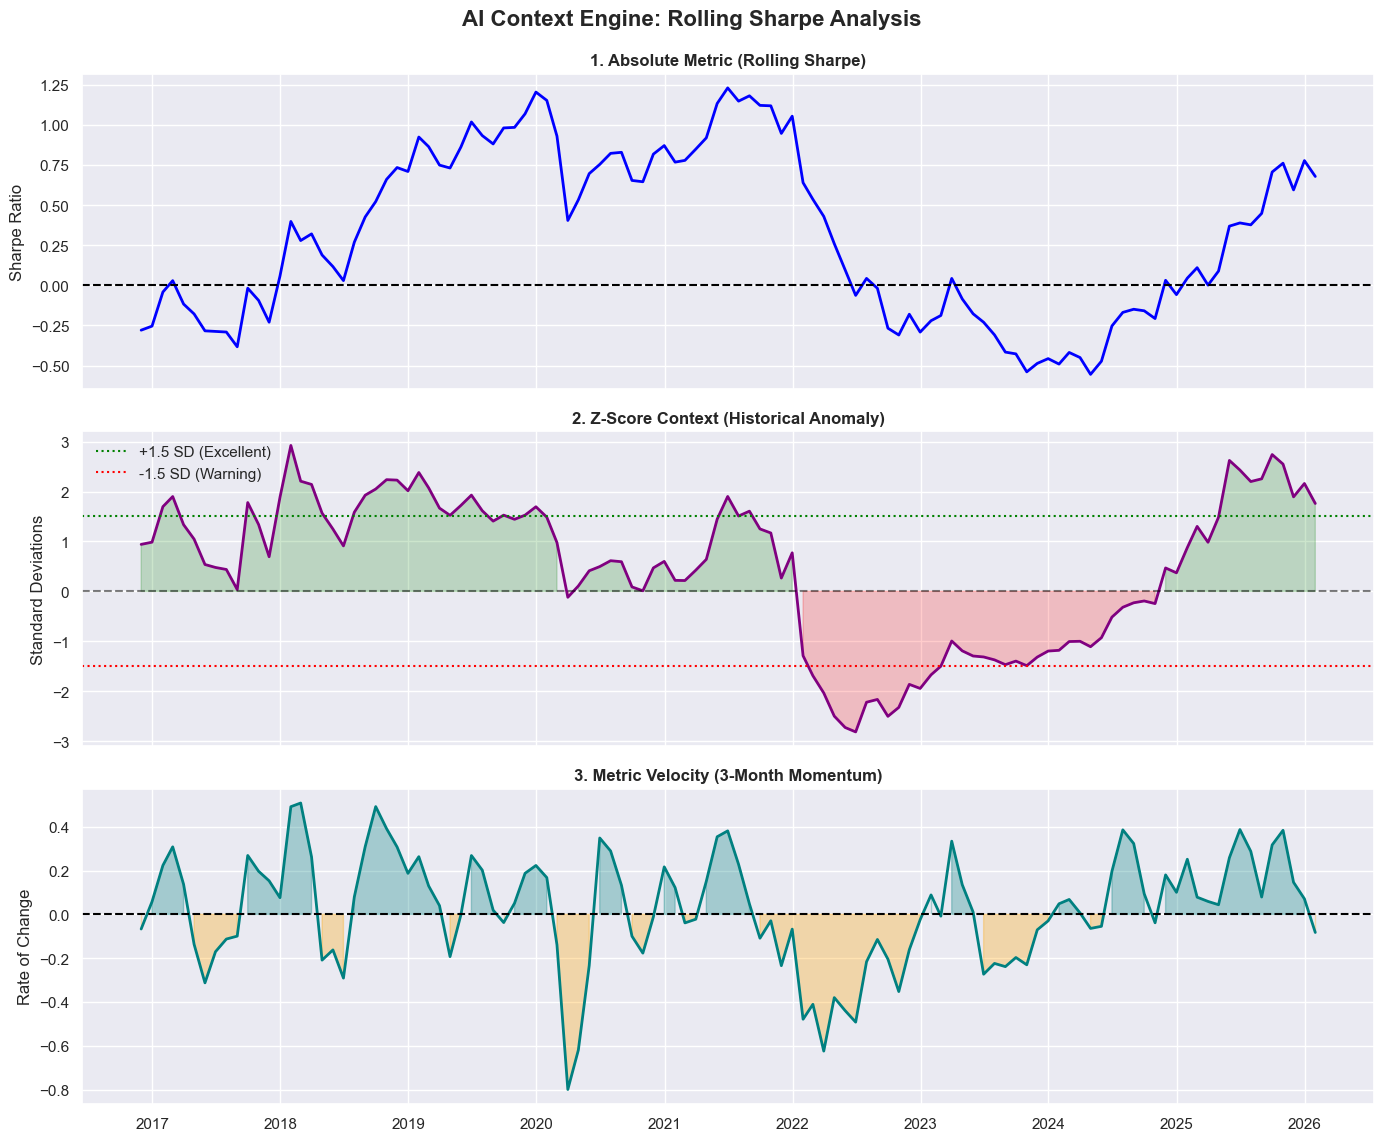

In [11]:
# ==============================================================================
# CELL 11: AI CONTEXT ENGINE (Z-SCORE & VELOCITY DASHBOARD)
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Choose the metric to analyze (e.g., Rolling Sharpe for the Portfolio)
window = 36
rolling_sharpe = analyzer.calc_rolling_sharpe('Portfolio', window=window)

# 2. Apply the new AI Context methods
# Calculate how anomalous the Sharpe is compared to its trailing 3-year average
z_score_sharpe = analyzer.calc_rolling_z_score(rolling_sharpe, window=window)

# Calculate the 3-month velocity (momentum) of the Sharpe ratio
velocity_sharpe = analyzer.calc_metric_velocity(rolling_sharpe, periods=3)

# 3. Align the series temporally to avoid plotting mismatched dates
df_context = pd.concat([rolling_sharpe, z_score_sharpe, velocity_sharpe], axis=1).dropna()
df_context.columns = ['Absolute_Sharpe', 'Z_Score', 'Velocity']

# 4. Build the Visual Dashboard
sns.set_theme(style="darkgrid")
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
fig.suptitle('AI Context Engine: Rolling Sharpe Analysis', fontsize=16, fontweight='bold', y=0.95)

# --- Plot 1: Absolute Value ---
ax1 = axes[0]
ax1.plot(df_context.index, df_context['Absolute_Sharpe'], color='blue', linewidth=2)
ax1.axhline(y=0, color='black', linestyle='--')
ax1.set_title('1. Absolute Metric (Rolling Sharpe)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Sharpe Ratio')

# --- Plot 2: Z-Score (Is it good or bad?) ---
ax2 = axes[1]
ax2.plot(df_context.index, df_context['Z_Score'], color='purple', linewidth=2)
# Add institutional standard deviation thresholds
ax2.axhline(y=1.5, color='green', linestyle=':', label='+1.5 SD (Excellent)')
ax2.axhline(y=-1.5, color='red', linestyle=':', label='-1.5 SD (Warning)')
ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax2.fill_between(df_context.index, df_context['Z_Score'], 0, where=(df_context['Z_Score'] > 0), color='green', alpha=0.2)
ax2.fill_between(df_context.index, df_context['Z_Score'], 0, where=(df_context['Z_Score'] < 0), color='red', alpha=0.2)
ax2.set_title('2. Z-Score Context (Historical Anomaly)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Standard Deviations')
ax2.legend(loc='upper left')

# --- Plot 3: Velocity (Is it improving or degrading?) ---
ax3 = axes[2]
ax3.plot(df_context.index, df_context['Velocity'], color='teal', linewidth=2)
ax3.axhline(y=0, color='black', linestyle='--')
ax3.fill_between(df_context.index, df_context['Velocity'], 0, where=(df_context['Velocity'] > 0), color='teal', alpha=0.3)
ax3.fill_between(df_context.index, df_context['Velocity'], 0, where=(df_context['Velocity'] < 0), color='orange', alpha=0.3)
ax3.set_title('3. Metric Velocity (3-Month Momentum)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Rate of Change')

plt.tight_layout(rect=[0, 0, 1, 0.96])

# Create the output directory one level up if it doesn't exist
os.makedirs('../outputs', exist_ok=True) 

# Save the figure securely before showing it
fig_path = '../outputs/ai_context_dashboard.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
        
plt.show()       

## AI Context Engine: Desconstruindo a Anatomia do Risco

Este painel triplo não apenas exibe o desempenho da carteira, mas traduz os dados brutos em inteligência acionável e probabilística. Ele é composto por três camadas complementares que respondem às perguntas fundamentais da gestão ativa: **"Qual é o número?", "Isso é estatisticamente bom?"** e **"Para onde estamos indo?"**.

### 1. Absolute Metric (Rolling Sharpe): O Sinal Bruto
* **O que mede:** Apresenta o valor absoluto do Índice de Sharpe em uma janela móvel (ex: 36 meses). Representa o prêmio de risco puro (retorno acima da taxa livre de risco) dividido pela volatilidade desse excesso.
* **Como interpretar:** A linha azul mostra a trajetória histórica do retorno ajustado ao risco. 
* **A Limitação:** Analisar este gráfico isoladamente é perigoso. Um Sharpe de `0.50` pode ser um resultado extraordinário num ano de *crash* global, mas um resultado medíocre num mercado de forte euforia (*bull market*). O número bruto carece de relatividade.

### 2. Z-Score Context (Historical Anomaly): A Lente da Relatividade
* **O que mede:** Calcula o *Z-Score* dinâmico da métrica absoluta. Ele normaliza o Sharpe subtraindo a sua média móvel e dividindo pelo seu desvio-padrão no período. 
* **Como interpretar:** Este gráfico responde à pergunta: *"Quão anômalo é o momento atual em relação à própria história recente da carteira?"*
    * **Linha Verde Pontilhada (+1.5 SD):** Entrar nesta zona significa que a carteira atingiu um patamar de **excelência estatística**. O portfólio está performando muito acima do seu próprio padrão "normal".
    * **Linha Vermelha Pontilhada (-1.5 SD):** Cruzar esta linha para baixo é um alerta vermelho de **estresse severo**. Indica uma degradação estrutural rara e acentuada na eficiência do portfólio.
    * **Preenchimento (Shading):** Zonas verdes indicam que a métrica está acima da sua média recente; zonas vermelhas indicam que está abaixo.

### 3. Metric Velocity (3-Month Momentum): O Acelerômetro
* **O que mede:** Representa a derivada primeira (a taxa de variação ou inclinação) do Índice de Sharpe em um período curto (ex: 3 meses). É o "momento" ou a velocidade da métrica.
* **Como interpretar:** Este é o radar de alerta precoce da carteira, focado inteiramente na tendência direcional.
    * **Território Positivo (Verde-Azulado):** A eficiência da carteira está a ganhar tração e a acelerar positivamente.
    * **Território Negativo (Laranja/Amarelo):** O portfólio perdeu força e a eficiência está a degradar-se ("sangrando"), mesmo que o valor absoluto no Gráfico 1 ainda pareça alto.
    * **O Cruzamento da Linha Zero:** O momento mais crítico do gráfico. Quando a linha cruza de cima para baixo, indica uma **inversão de tendência** (o pé saiu do acelerador). Quando cruza de baixo para cima, indica o fim de uma crise e o início da recuperação do sistema.

In [12]:
# Print the JSON payload for the AI
ai_payload = analyzer.export_ai_context_json('Portfolio')
print(ai_payload)

{
    "portfolio_ticker": "Portfolio",
    "analysis_date": "2026-01-31",
    "lookback_window_months": 36,
    "metrics": {
        "Rolling_Sharpe": {
            "absolute_value": 0.6778,
            "z_score": 1.7605,
            "velocity_3m": -0.0826
        },
        "Rolling_Volatility": {
            "absolute_value": 0.1136,
            "z_score": -1.0487,
            "velocity_3m": -0.0031
        },
        "Rolling_Max_Drawdown": {
            "absolute_value": -0.1568,
            "z_score": 3.0895,
            "velocity_3m": 0.0132
        }
    }
}


In [13]:
# ==============================================================================
# CELL 12: AGENTIC AI INTEGRATION (GEMINI API - NEW SDK)
# ==============================================================================
import os
from dotenv import load_dotenv, find_dotenv
from google import genai
from google.genai import types

# O find_dotenv() sobe as pastas automaticamente e acha o arquivo na raiz
load_dotenv(find_dotenv())

# 1. Load environment variables securely from the .env file
load_dotenv()
API_KEY = os.getenv("GEMINI_API_KEY")

if not API_KEY:
    print("❌ ERROR: API Key not found. Please create a .env file and set GEMINI_API_KEY.")
else:
    # 2. Initialize the new Gemini client
    client = genai.Client(api_key=API_KEY)

    # 3. Define the System Prompt (The Persona and Rules)
    system_prompt = """
    You are a Senior Quantitative Portfolio Manager analyzing a monthly portfolio close. 
    Analyze the provided JSON containing 36-month rolling risk metrics. 
    
    Rules:
    - Z-Scores > 1.5 indicate excellence or extreme positive deviation.
    - Z-Scores < -1.5 indicate severe stress or compression.
    - Velocity indicates the 3-month directional trend. 
    
    Write a direct, professional 2-3 paragraph diagnostic report in Portuguese 
    interpreting the relationship between the absolute value, historical context (Z-Score), 
    and momentum (Velocity). Do not use vague jargon. Cite the specific numbers provided.
    """

    # 4. Fetch the mathematical context directly from your OOP engine
    ai_payload = analyzer.export_ai_context_json('Portfolio')

    # 5. Call the API and generate the autonomous report using the new SDK
    print("🤖 Sending mathematical context to Gemini API...\n")
    try:
        # Using the standard updated flash model
        response = client.models.generate_content(
            model='gemini-2.5-flash',
            contents=ai_payload,
            config=types.GenerateContentConfig(
                system_instruction=system_prompt,
            )
        )
        
        print("="*80)
        print(" GEMINI QUANTITATIVE DIAGNOSTIC REPORT ")
        print("="*80)
        print(response.text)
        print("="*80)
        
    except Exception as e:
        print(f"❌ API Call Failed: {e}")

🤖 Sending mathematical context to Gemini API...

 GEMINI QUANTITATIVE DIAGNOSTIC REPORT 
**Relatório de Diagnóstico de Risco do Portfólio (2026-01-31)**

O portfólio apresenta um Rolling Sharpe Ratio de 0.6778. Com um Z-Score de 1.7605, este valor posiciona o Sharpe Ratio numa categoria de desempenho excelente, significativamente acima da sua média histórica nos últimos 36 meses, demonstrando uma geração de retorno ajustado ao risco superior. Contudo, a velocidade nos últimos três meses é negativa em -0.0826, sugerindo que este desempenho robusto está a experienciar uma perda de impulso recente.

Em relação à Rolling Volatility, o portfólio registra um valor de 0.1136. O Z-Score de -1.0487 indica que a volatilidade atual está ligeiramente abaixo da sua média histórica, embora não atinja um nível de compressão severa. A velocidade trimestral de -0.0031 aponta para uma marginal continuação da tendência de redução da volatilidade. Quanto ao Rolling Max Drawdown, o valor atual é de -0.1568

In [14]:
# ==============================================================================
# CELL 13: AUTOMATED REPORT GENERATION (MARKDOWN TO PDF)
# ==============================================================================
import os
import datetime

# 1. Garantir que a pasta correta (outputs) existe
os.makedirs('../outputs', exist_ok=True)

# 2. Definir o nome do arquivo e a data
report_date = datetime.date.today().strftime("%Y-%m-%d")
report_filename = f"../outputs/Quant_Diagnostic_Report_{report_date}.md"

# 3. Extrair os KPIs corretamente da sua classe PortfolioMetrics
cagr = analyzer.calc_cagr('Portfolio') * 100
volatility = analyzer.calc_volatility('Portfolio') * 100
sharpe = analyzer.calc_sharpe('Portfolio')
max_dd = analyzer.calc_max_drawdown('Portfolio') * 100

# Variável auxiliar para evitar conflito de formatação no Markdown
md_code_block = "```"

# 4. Estrutura limpa e validada do documento Markdown
markdown_content = f"""# Quantitative Diagnostic Report
**Date:** {report_date}
**Asset/Portfolio:** Regime 2 (Core-Satellite Foundation)

---

## 1. Executive Summary (KPIs)
| Metric | Value |
| :--- | :--- |
| **CAGR** | {cagr:.2f}% |
| **Volatility** | {volatility:.2f}% |
| **Sharpe Ratio** | {sharpe:.2f} |
| **Max Drawdown** | {max_dd:.2f}% |

---

## 2. Autonomous Agent Analysis
{response.text}

---

## 3. Mathematical Context Dashboard
![AI Context Dashboard](./ai_context_dashboard.png)

---

## 4. Technical Audit Annex (JSON Payload)
The raw data below was processed by the LLM to generate the analysis.

{md_code_block}json
{ai_payload}
{md_code_block}
"""

# 5. Salvar o relatório na pasta outputs
with open(report_filename, "w", encoding="utf-8") as file:
    file.write(markdown_content)

print(f"✅ Relatório gerado com sucesso e salvo em: {report_filename}")
print("💡 Dica: Abra o arquivo .md na pasta 'outputs', clique com o botão direito e selecione 'Markdown PDF: Export (pdf)'")

✅ Relatório gerado com sucesso e salvo em: ../outputs/Quant_Diagnostic_Report_2026-03-24.md
💡 Dica: Abra o arquivo .md na pasta 'outputs', clique com o botão direito e selecione 'Markdown PDF: Export (pdf)'


✅ Arquivo de sinais sintéticos criado em: ../data/synthetic_xgboost_signals.csv

 🚀 IMPACTO DO MODELO DE MACHINE LEARNING (SIMULAÇÃO)
CAGR Original: 10.44%
CAGR Enhanced: 12.90%
Diferença Anual: +2.46% ao ano!


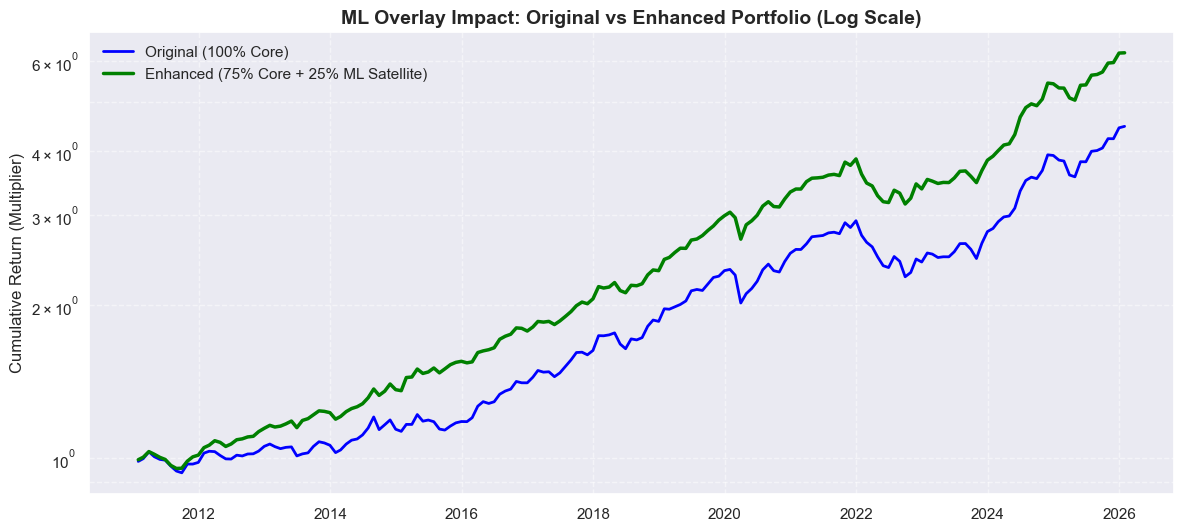

In [15]:
# ==============================================================================
# CELL 14: ML OVERLAY (CORE-SATELLITE SIMULATOR)
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# 1. CREATE SYNTHETIC ML DATA (Mocking the spy_xgboost_swing output)
# ------------------------------------------------------------------------------
# Criando um arquivo CSV simulado na pasta data para imitar o seu fluxo real.
np.random.seed(42) # Para o resultado ser o mesmo toda vez que você rodar
dates = comp_df.index

# Lógica do "Modelo Sintético": Acerta 70% dos meses de alta e protege em 60% dos de baixa
mkt_returns = comp_df['Global_BRL']
synthetic_signals = []
for ret in mkt_returns:
    if ret > 0:
        signal = np.random.choice([1, 0], p=[0.7, 0.3]) 
    else:
        signal = np.random.choice([1, 0], p=[0.4, 0.6]) 
    synthetic_signals.append(signal)
    
df_signals = pd.DataFrame({'Date': dates, 'Signal': synthetic_signals})

# Salva no disco (Exatamente como o seu futuro script fará)
csv_path = '../data/synthetic_xgboost_signals.csv'
df_signals.to_csv(csv_path, index=False)
print(f"✅ Arquivo de sinais sintéticos criado em: {csv_path}")

# 2. LOAD AND MERGE ML SIGNALS
# ------------------------------------------------------------------------------
# Lê o CSV e alinha as datas com a nossa base principal
ml_data = pd.read_csv(csv_path)
ml_data['Date'] = pd.to_datetime(ml_data['Date'])
ml_data.set_index('Date', inplace=True)

sim_df = comp_df.copy()
sim_df = sim_df.join(ml_data['Signal'])
sim_df['Signal'] = sim_df['Signal'].fillna(0) # Se faltar sinal, segurança primeiro (Caixa/0)

# 3. CORE-SATELLITE LOGIC
# ------------------------------------------------------------------------------
CORE_WEIGHT = 0.75      # 75% na estratégia passiva atual
SATELLITE_WEIGHT = 0.25 # 25% operando os sinais de Machine Learning

# Se Signal == 1, o satélite rende Global_BRL. Se Signal == 0, rende CDI (Proteção).
sim_df['Satellite_Return'] = np.where(sim_df['Signal'] == 1, sim_df['Global_BRL'], sim_df['CDI'])

# O Retorno Turbinado = (Peso Core * Retorno Core) + (Peso Satélite * Retorno Satélite)
sim_df['Portfolio_Enhanced'] = (sim_df['Portfolio'] * CORE_WEIGHT) + (sim_df['Satellite_Return'] * SATELLITE_WEIGHT)

# 4. VISUALIZATION & KPI COMPARISON
# ------------------------------------------------------------------------------
wealth_original = (1 + sim_df['Portfolio']).cumprod()
wealth_enhanced = (1 + sim_df['Portfolio_Enhanced']).cumprod()

plt.figure(figsize=(14, 6))
plt.plot(wealth_original.index, wealth_original, label='Original (100% Core)', color='blue', linewidth=2)
plt.plot(wealth_enhanced.index, wealth_enhanced, label=f'Enhanced ({CORE_WEIGHT*100:.0f}% Core + {SATELLITE_WEIGHT*100:.0f}% ML Satellite)', color='green', linewidth=2.5)

plt.title('ML Overlay Impact: Original vs Enhanced Portfolio (Log Scale)', fontsize=14, fontweight='bold')
plt.yscale('log')
plt.ylabel('Cumulative Return (Multiplier)')
plt.legend(loc='upper left')
plt.grid(True, which="both", ls="--", alpha=0.5)

# Métricas rápidas
cagr_orig = (wealth_original.iloc[-1] ** (12 / len(wealth_original))) - 1
cagr_enh = (wealth_enhanced.iloc[-1] ** (12 / len(wealth_enhanced))) - 1

print("\n" + "="*60)
print(" 🚀 IMPACTO DO MODELO DE MACHINE LEARNING (SIMULAÇÃO)")
print("="*60)
print(f"CAGR Original: {cagr_orig*100:.2f}%")
print(f"CAGR Enhanced: {cagr_enh*100:.2f}%")
print(f"Diferença Anual: {(cagr_enh - cagr_orig)*100:+.2f}% ao ano!")
print("="*60)

plt.show()

In [16]:
# ==============================================================================
# CELL 15: MACRO ANALYST AGENT & REPORT UPDATE
# ==============================================================================
import yfinance as yf
import os
import datetime
from dotenv import load_dotenv, find_dotenv
from google import genai

# O find_dotenv() sobe as pastas automaticamente e acha o arquivo na raiz
load_dotenv(find_dotenv())

# 1. Fetch real-time macroeconomic news using yfinance
print("🌍 Fetching real-time macroeconomic news...")
try:
    # Fetching news for S&P 500 (Global context) and USD/BRL (Local/FX context)
    sp500_news = yf.Ticker("^GSPC").news
    usdcrl_news = yf.Ticker("BRL=X").news
    
    headlines = []
    # Extract the top 3 headlines for each market
    for item in sp500_news[:3]: 
        headlines.append(f"- Global: {item.get('title', '')}")
    for item in usdcrl_news[:3]: 
        headlines.append(f"- Emerging/FX: {item.get('title', '')}")
        
    news_context = "\n".join(headlines)
except Exception as e:
    news_context = "Could not fetch real-time news from Yahoo Finance."
    print(f"Warning: {e}")

# 2. Setup the Macro Agent via Gemini API
load_dotenv()
api_key = os.getenv("GEMINI_API_KEY")
client = genai.Client(api_key=api_key)

# 3. Define the Macro Agent persona and prompt
macro_prompt = f"""
You are a Chief Macroeconomic Strategist at a quantitative hedge fund.
Below are the top financial headlines for global markets and Emerging/FX today:

{news_context}

Based on these headlines and your general knowledge of the current economic cycle, 
write a single, highly institutional paragraph summarizing the current macroeconomic 
climate (focusing on interest rates, inflation, and risk appetite). 
Write the final output in Portuguese (Portugal).
"""

print("🤖 Asking the Macro Agent for market context...")
macro_response = client.models.generate_content(
    model='gemini-2.5-flash',
    contents=macro_prompt
)

macro_text = macro_response.text

# 4. Update the Markdown Report with the new Agent's text
# Re-extracting KPIs to ensure the report has the latest data
cagr = analyzer.calc_cagr('Portfolio') * 100
volatility = analyzer.calc_volatility('Portfolio') * 100
sharpe = analyzer.calc_sharpe('Portfolio')
max_dd = analyzer.calc_max_drawdown('Portfolio') * 100

report_date = datetime.date.today().strftime("%Y-%m-%d")
report_filename = f"../outputs/Quant_Diagnostic_Report_{report_date}.md"

# Auxiliary variable to avoid Markdown formatting conflicts in the string
md_code_block = "```"

# Build the updated Markdown content including the Macro Agent
markdown_content = f"""# Quantitative Diagnostic Report
**Date:** {report_date}
**Asset/Portfolio:** Regime 2 (Core-Satellite Foundation)

---

## 1. Executive Summary (KPIs)
| Metric | Value |
| :--- | :--- |
| **CAGR** | {cagr:.2f}% |
| **Volatility** | {volatility:.2f}% |
| **Sharpe Ratio** | {sharpe:.2f} |
| **Max Drawdown** | {max_dd:.2f}% |

---

## 2. Macroeconomic Context (Macro Agent)
{macro_text}

---

## 3. Autonomous Agent Analysis (Quant Agent)
{response.text}

---

## 4. Mathematical Context Dashboard
![AI Context Dashboard](./ai_context_dashboard.png)

---

## 5. Technical Audit Annex (JSON Payload)
The raw data below was processed by the LLM to generate the analysis.

{md_code_block}json
{ai_payload}
{md_code_block}
"""

# 5. Save the updated report to the disk
os.makedirs('../outputs', exist_ok=True)
with open(report_filename, "w", encoding="utf-8") as file:
    file.write(markdown_content)

print(f"✅ Updated multi-agent report generated successfully: {report_filename}")

🌍 Fetching real-time macroeconomic news...
🤖 Asking the Macro Agent for market context...
✅ Updated multi-agent report generated successfully: ../outputs/Quant_Diagnostic_Report_2026-03-24.md
